# DI725 Assignment 2 - Transformer-Based Object Detection with RT-DETR + SAHI






## Environment setup

Install all required packages for training, evaluation, and SAHI-based sliced inference.




In [ ]:
!pip -q install ultralytics sahi pycocotools opencv-python pandas matplotlib pyyaml wandb



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 15.4 MB/s eta 0:00:00


## Mount Google Drive and define project paths

Expected Drive layout (either folder name works):
- `/content/drive/MyDrive/di725_a2/auair2019.zip`
- `/content/drive/MyDrive/di725 a2/auair2019.zip`

The notebook copies the ZIP to local `/content` and extracts it there to avoid Google Drive I/O errors during training.




In [ ]:
from pathlib import Path
import os

from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
# Prepare dataset from ZIP on Drive -> local runtime (/content) for stable I/O.
import shutil
import zipfile

CANDIDATE_DRIVE_DIRS = [
    Path('/content/drive/MyDrive/di725_a2'),
    Path('/content/drive/MyDrive/di725 a2'),
]
DRIVE_DIR = next((p for p in CANDIDATE_DRIVE_DIRS if p.exists()), None)
if DRIVE_DIR is None:
    raise FileNotFoundError(
        'Could not find assignment folder in MyDrive. Expected one of: di725_a2 or di725 a2'
    )

ZIP_PATH = DRIVE_DIR / 'auair2019.zip'
if not ZIP_PATH.exists():
    raise FileNotFoundError(f'Missing ZIP file: {ZIP_PATH}')

LOCAL_ZIP = Path('/content/auair2019.zip')
LOCAL_DATA_DIR = Path('/content/auair2019')


def local_dataset_ready(root: Path) -> bool:
    images_dir = root / 'images'
    return (
        (root / 'annotations.json').exists()
        and images_dir.exists()
        and any(images_dir.glob('*.jpg'))
    )


if local_dataset_ready(LOCAL_DATA_DIR):
    print('Local extracted dataset already exists, skipping copy/extract:', LOCAL_DATA_DIR)
else:
    if LOCAL_DATA_DIR.exists():
        shutil.rmtree(LOCAL_DATA_DIR)

    if LOCAL_ZIP.exists():
        LOCAL_ZIP.unlink()

    print('Copying ZIP to local runtime:', ZIP_PATH, '->', LOCAL_ZIP)
    shutil.copy2(ZIP_PATH, LOCAL_ZIP)

    print('Extracting ZIP into /content ...')
    with zipfile.ZipFile(LOCAL_ZIP, 'r') as zf:
        zf.extractall('/content')

    # Normalize potential nested layout: /content/auair2019/auair2019
    nested = LOCAL_DATA_DIR / 'auair2019'
    if nested.exists() and (nested / 'annotations.json').exists() and (nested / 'images').exists():
        for item in nested.iterdir():
            target = LOCAL_DATA_DIR / item.name
            if target.exists():
                if target.is_dir():
                    shutil.rmtree(target)
                else:
                    target.unlink()
            shutil.move(str(item), str(target))
        shutil.rmtree(nested)

if not local_dataset_ready(LOCAL_DATA_DIR):
    raise RuntimeError(
        f'Local dataset is not ready after extraction: {LOCAL_DATA_DIR}. '
        'Expected annotations.json and images/*.jpg'
    )

print('Using DRIVE_DIR:', DRIVE_DIR)
print('Using ZIP_PATH:', ZIP_PATH)
print('Using LOCAL_DATA_DIR:', LOCAL_DATA_DIR)




Copying ZIP to local runtime: /content/drive/MyDrive/di725_a2/auair2019.zip -> /content/auair2019.zip
Extracting ZIP into /content ...
Using DRIVE_DIR: /content/drive/MyDrive/di725_a2
Using ZIP_PATH: /content/drive/MyDrive/di725_a2/auair2019.zip
Using LOCAL_DATA_DIR: /content/auair2019


In [ ]:
# Drive: backup destination
BACKUP_ROOT = DRIVE_DIR / 'colab_outputs'

# Local: fast I/O for conversion/training/eval
ANNOTATIONS = LOCAL_DATA_DIR / 'annotations.json'
IMAGES_DIR = LOCAL_DATA_DIR / 'images'
YOLO_ROOT = Path('/content/auair_yolo')
RUNS_ROOT = Path('/content/runs/di725')
RESULTS_ROOT = Path('/content/results')

# W&B settings
USE_WANDB = True
WANDB_PROJECT = 'di725-rtdetr-sahi'
WANDB_ENTITY = None

# Run toggles
RUN_SMOKE = False
RUN_EXP1 = TRUE
RUN_EXP2 = TRUE
RUN_FREEZE_EXP = False
RUN_MODEL_ABLATION_EVAL = True
RUN_SAHI_EVAL = True

# Evaluation split for quick model-to-model comparison
EVAL_SPLIT = 'val'

# Keep current working directory on local disk
os.chdir('/content')

RUNS_ROOT.mkdir(parents=True, exist_ok=True)
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
BACKUP_ROOT.mkdir(parents=True, exist_ok=True)

print('ANNOTATIONS exists:', ANNOTATIONS.exists(), ANNOTATIONS)
print('IMAGES_DIR exists:', IMAGES_DIR.exists(), IMAGES_DIR)
print('YOLO_ROOT:', YOLO_ROOT)
print('RUNS_ROOT:', RUNS_ROOT)
print('RESULTS_ROOT:', RESULTS_ROOT)
print('USE_WANDB:', USE_WANDB)
print('RUN flags:', {
    'RUN_SMOKE': RUN_SMOKE,
    'RUN_EXP1': RUN_EXP1,
    'RUN_EXP2': RUN_EXP2,
    'RUN_FREEZE_EXP': RUN_FREEZE_EXP,
    'RUN_MODEL_ABLATION_EVAL': RUN_MODEL_ABLATION_EVAL,
    'RUN_SAHI_EVAL': RUN_SAHI_EVAL,
})



ANNOTATIONS exists: True /content/auair2019/annotations.json
IMAGES_DIR exists: True /content/auair2019/images
YOLO_ROOT: /content/auair_yolo
RUNS_ROOT: /content/runs/di725
RESULTS_ROOT: /content/results
USE_WANDB: True
RUN flags: {'RUN_SMOKE': False, 'RUN_EXP1': False, 'RUN_EXP2': False, 'RUN_FREEZE_EXP': False, 'RUN_MODEL_ABLATION_EVAL': True, 'RUN_SAHI_EVAL': True}


## Experiment configuration 

This section locks all major decisions:
- class list,
- sequence-based split,
- baseline values,
- training hyperparameters,
- SAHI settings.

I also assert there is no overlap between train/val/test sequence sets.




In [ ]:
SEED = 42

CLASS_NAMES = [
    'Human', 'Car', 'Truck', 'Van',
    'Motorbike', 'Bicycle', 'Bus', 'Trailer'
]

# Sequence-based split to prevent temporal leakage between train/val/test.
SPLIT_CFG = {
    'train': [
        '20190905103112_x', '20190905112522_x', '20190905091750_x', '20190906150731_x',
        '20190829091111_x', '20190905111947_x', '20190905091750_xx', '20190905112522_xx'
    ],
    'val': ['20190905142119_x', '20190905103112_xx'],
    'test': ['20190905143505_x', '20190906150731_xx'],
}

# Baseline mAP values from assignment handout.
BASELINE_MAP50 = {
    'YOLOv3-tiny': 30.22,
    'MobileNetV2-SSDLite': 19.50,
}

#  Both experiments 10 epochs, mosaic disabled.
EXP1 = dict(model='rtdetr-l.pt', imgsz=640, epochs=10, batch=16, lr0=1e-4, patience=4, mosaic=0.0, close_mosaic=0)
EXP2 = dict(model='rtdetr-l.pt', imgsz=960, epochs=10, batch=8, lr0=5e-5, patience=4, mosaic=0.0, close_mosaic=0)

# Additional freeze experiment (mosaic disabled): freeze first 10 layers.
EXP_FREEZE = dict(model='rtdetr-l.pt', imgsz=960, epochs=10, batch=8, lr0=5e-5, patience=4, mosaic=0.0, close_mosaic=0, freeze=10)

# SAHI slicing configuration.
SAHI_CFG = dict(slice_height=640, slice_width=640, overlap=0.25)

# Hard checks for leakage prevention.
assert set(SPLIT_CFG['train']).isdisjoint(SPLIT_CFG['val'])
assert set(SPLIT_CFG['train']).isdisjoint(SPLIT_CFG['test'])
assert set(SPLIT_CFG['val']).isdisjoint(SPLIT_CFG['test'])

print('Split integrity check passed. Sequence overlap = 0')
print('Exp configs:')
print('EXP1:', EXP1)
print('EXP2:', EXP2)
print('EXP_FREEZE:', EXP_FREEZE)



Split integrity check passed. Sequence overlap = 0
Exp configs:
EXP1: {'model': 'rtdetr-l.pt', 'imgsz': 640, 'epochs': 10, 'batch': 16, 'lr0': 0.0001, 'patience': 4, 'mosaic': 0.0, 'close_mosaic': 0}
EXP2: {'model': 'rtdetr-l.pt', 'imgsz': 960, 'epochs': 10, 'batch': 8, 'lr0': 5e-05, 'patience': 4, 'mosaic': 0.0, 'close_mosaic': 0}
EXP_FREEZE: {'model': 'rtdetr-l.pt', 'imgsz': 960, 'epochs': 10, 'batch': 8, 'lr0': 5e-05, 'patience': 4, 'mosaic': 0.0, 'close_mosaic': 0, 'freeze': 10}


##  Weights & Biases setup





In [ ]:
import wandb

if USE_WANDB:
    try:
        wandb.login()
        print('W&B login successful.')
    except Exception as e:
        USE_WANDB = False
        print(f'W&B login failed, disabling W&B logging: {e}')
else:
    print('USE_WANDB=False -> skipping W&B login.')



/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: yesim-kocoglu (yesim-kocoglu-metu-middle-east-technical-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B login successful.


# Pipeline Overview: AU-AIR to YOLO Conversion
This cell converts AU-AIR annotations into the YOLO format. It ensures robust dataset generation by preventing data leakage, sanitizing bounding boxes, and normalizing spatial coordinates.

### 1. Sequence-Aware Split (Anti-Leakage)
- **Temporal Integrity:** Parse each filename (`frame_<timestamp>_<variant>_<id>.jpg`) and assign it to train/val/test using `SPLIT_CFG`.
- **Preventing Leakage:** Perform a sequence-based split rather than a random image-level split. Since consecutive video frames are highly similar, this strict separation prevents temporal leakage between datasets.

### 2. Bounding Box Sanitization
AU-AIR boxes are originally formatted as `(top, left, width, height)` in absolute pixel coordinates.
- **Clipping:** The `clamp_bbox()` function restricts boxes precisely to the image boundaries `[0..W, 0..H]`.
- **Filtering:** Any box that becomes degenerate (e.g., `width <= 0` or `height <= 0`) after clipping is discarded. Annotations with out-of-bounds class IDs are also ignored.
- **Traceability:** Filtering these anomalies prevents training crashes and label noise. Dropped boxes are counted under `stats['invalid_boxes']` for tracking and reproducibility.

### 3. YOLO Label Conversion
- Valid annotations are processed through `to_yolo()`, which converts them into the normalized YOLO format: `class_id x_center y_center width height` (all values between `[0, 1]`).
- **Resolution Independence:** Normalization makes the labels robust across varying input sizes. The exact same generated labels can be used for both baseline experiments (e.g., `imgsz=640`) and high-resolution runs (`imgsz=960`).

### 4. File Transfer Strategy (`copy_mode`)
- **`symlink`:** Fast and highly storage-efficient. Best suited for local or temporary environments like `/content` in Colab.
- **`copy`:** Physically copies the files. Recommended for environments like Google Drive mounts where symlinks are often unsupported.

### 5. Output Structure
The execution yields a complete, training-ready YOLO dataset:
- `images/{train,val,test}/` & `labels/{train,val,test}/`: The core dataset split.
- `data.yaml`: Ultralytics configuration file containing paths and class names.
- `prepare_summary.json`: Detailed preparation telemetry (processed/missing/invalid counts and class distributions) for experiment reproducibility.





In [ ]:
import json
import re
import shutil
from collections import Counter, defaultdict

IMAGE_RE = re.compile(r'^frame_(\d{14})_([a-z]+)_\d+\.jpg$')


def extract_sequence(image_name: str):
    """Extract sequence key (timestamp + variant) from AU-AIR frame filename."""
    m = IMAGE_RE.match(image_name)
    if not m:
        return None
    return f"{m.group(1)}_{m.group(2)}"


def clamp_bbox(left, top, width, height, img_w, img_h):
    """Clip bbox into image boundaries and reject degenerate boxes."""
    x1 = max(0.0, min(left, img_w))
    y1 = max(0.0, min(top, img_h))
    x2 = max(0.0, min(left + width, img_w))
    y2 = max(0.0, min(top + height, img_h))
    w = x2 - x1
    h = y2 - y1
    if w <= 0 or h <= 0:
        return None
    return x1, y1, w, h


def to_yolo(cls_id, x, y, w, h, img_w, img_h):
    """Convert absolute XYWH box to normalized YOLO center format."""
    xc = (x + w / 2.0) / img_w
    yc = (y + h / 2.0) / img_h
    return f"{cls_id} {xc:.6f} {yc:.6f} {w/img_w:.6f} {h/img_h:.6f}"


def prepare_auair_yolo(annotations_path, images_dir, out_root, split_cfg, class_names, copy_mode='copy'):
    """Create YOLO dataset folder with deterministic split and labels."""
    out_root = Path(out_root)
    img_root = out_root / 'images'
    lbl_root = out_root / 'labels'

    # Rebuild output directory for a clean, reproducible conversion.
    if out_root.exists():
        print('Cleaning existing output:', out_root)
        shutil.rmtree(out_root)

    for split in ('train', 'val', 'test'):
        (img_root / split).mkdir(parents=True, exist_ok=True)
        (lbl_root / split).mkdir(parents=True, exist_ok=True)

    seq_to_split = {}
    for split, seqs in split_cfg.items():
        for s in seqs:
            seq_to_split[s] = split

    with open(annotations_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    stats = Counter()
    per_split_images = Counter()
    per_split_boxes = Counter()
    per_split_classes = defaultdict(Counter)

    for entry in data['annotations']:
        image_name = entry.get('image_name')
        if not image_name:
            continue

        seq = extract_sequence(image_name)
        if seq not in seq_to_split:
            continue
        split = seq_to_split[seq]

        src_img = Path(images_dir) / image_name
        if not src_img.exists():
            stats['missing_images'] += 1
            continue

        img_w = float(entry.get('image_width:', entry.get('image_width', 1920.0)))
        img_h = float(entry.get('image_height', 1080.0))

        lines = []
        for b in entry.get('bbox', []):
            cls = int(b.get('class', -1))
            if cls < 0 or cls >= len(class_names):
                stats['invalid_boxes'] += 1
                continue

            clamped = clamp_bbox(
                float(b['left']), float(b['top']),
                float(b['width']), float(b['height']),
                img_w, img_h,
            )
            if clamped is None:
                stats['invalid_boxes'] += 1
                continue

            x, y, w, h = clamped
            lines.append(to_yolo(cls, x, y, w, h, img_w, img_h))
            per_split_classes[split][cls] += 1

        dst_img = img_root / split / image_name
        if copy_mode == 'copy':
            shutil.copy2(src_img, dst_img)
        else:
            dst_img.symlink_to(src_img.resolve())

        dst_lbl = lbl_root / split / (Path(image_name).stem + '.txt')
        dst_lbl.write_text(('\n'.join(lines) + '\n') if lines else '', encoding='utf-8')

        stats['processed_images'] += 1
        stats['written_boxes'] += len(lines)
        per_split_images[split] += 1
        per_split_boxes[split] += len(lines)

    # Save data.yaml for Ultralytics.
    data_yaml = {
        'path': str(out_root.resolve()),
        'train': 'images/train',
        'val': 'images/val',
        'test': 'images/test',
        'nc': len(class_names),
        'names': class_names,
    }

    import yaml
    with (out_root / 'data.yaml').open('w', encoding='utf-8') as f:
        yaml.safe_dump(data_yaml, f, sort_keys=False)

    summary = {
        'stats': dict(stats),
        'images_per_split': dict(per_split_images),
        'boxes_per_split': dict(per_split_boxes),
        'classes_per_split': {
            split: {class_names[c]: n for c, n in sorted(counts.items())}
            for split, counts in per_split_classes.items()
        }
    }
    (out_root / 'prepare_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')

    print(json.dumps(summary, indent=2))
    return summary

prepare_summary = prepare_auair_yolo(
    ANNOTATIONS, IMAGES_DIR, YOLO_ROOT, SPLIT_CFG, CLASS_NAMES, copy_mode='copy'
)




{
  "stats": {
    "processed_images": 32823,
    "written_boxes": 131977,
    "invalid_boxes": 54
  },
  "images_per_split": {
    "train": 24000,
    "val": 4914,
    "test": 3909
  },
  "boxes_per_split": {
    "train": 87754,
    "val": 23406,
    "test": 20817
  },
  "classes_per_split": {
    "train": {
      "Human": 3695,
      "Car": 67033,
      "Truck": 6982,
      "Van": 7136,
      "Motorbike": 189,
      "Bicycle": 561,
      "Bus": 627,
      "Trailer": 1531
    },
    "val": {
      "Human": 551,
      "Car": 18536,
      "Truck": 1721,
      "Van": 1662,
      "Motorbike": 38,
      "Bicycle": 332,
      "Bus": 39,
      "Trailer": 527
    },
    "test": {
      "Human": 906,
      "Car": 17012,
      "Truck": 837,
      "Van": 1194,
      "Motorbike": 91,
      "Bicycle": 235,
      "Bus": 63,
      "Trailer": 479
    }
  }
}


### Debug for dropped boxes (invalid annotations)

This section helps explain why some boxes are dropped during conversion.
It shows dropped-box counts by reason and visualizes examples separately for each reason.




In [ ]:
# Inspect dropped boxes and visualize them.
import random
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from collections import Counter


def inspect_dropped_boxes(annotations_path, images_dir, split_cfg, class_names, sample_n=12, seed=42):
    """Inspect boxes dropped during conversion and summarize reasons."""
    random.seed(seed)

    # Match the exact split filtering logic used in conversion.
    seq_to_split = {seq: split for split, seqs in split_cfg.items() for seq in seqs}
    dropped = []

    with open(annotations_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    for entry in data["annotations"]:
        image_name = entry.get("image_name")
        if not image_name:
            continue

        seq = extract_sequence(image_name)
        if seq not in seq_to_split:
            continue

        img_w = float(entry.get("image_width:", entry.get("image_width", 1920.0)))
        img_h = float(entry.get("image_height", 1080.0))

        for b in entry.get("bbox", []):
            cls = int(b.get("class", -1))
            if cls < 0 or cls >= len(class_names):
                dropped.append({
                    "reason": "invalid_class",
                    "image_name": image_name,
                    "class_raw": b.get("class"),
                    "left": b.get("left"),
                    "top": b.get("top"),
                    "width": b.get("width"),
                    "height": b.get("height"),
                })
                continue

            clamped = clamp_bbox(
                float(b["left"]), float(b["top"]),
                float(b["width"]), float(b["height"]),
                img_w, img_h
            )
            if clamped is None:
                dropped.append({
                    "reason": "degenerate_after_clamp",
                    "image_name": image_name,
                    "class_raw": b.get("class"),
                    "left": b.get("left"),
                    "top": b.get("top"),
                    "width": b.get("width"),
                    "height": b.get("height"),
                })

    df = pd.DataFrame(dropped)
    counts = Counter(df["reason"]) if len(df) else Counter()

    print("Dropped box counts:", dict(counts))
    display(df.head(20))

    out_csv = Path(YOLO_ROOT) / "dropped_boxes_debug.csv"
    df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)

    return df


def show_reason_grid(df, reason, images_dir, n=12, seed=42):
    """Visualize problematic boxes for one drop reason."""
    sub = df[df["reason"] == reason].copy()
    print(f"{reason}: {len(sub)} boxes")
    if len(sub) == 0:
        return

    sample = sub.sample(min(n, len(sub)), random_state=seed).to_dict("records")
    cols = 3
    rows = (len(sample) + cols - 1) // cols
    plt.figure(figsize=(6 * cols, 4.5 * rows))

    for i, r in enumerate(sample, 1):
        img_path = Path(images_dir) / r["image_name"]
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        # Draw the original problematic bbox in red.
        try:
            l = int(float(r["left"]))
            t = int(float(r["top"]))
            w = int(float(r["width"]))
            h = int(float(r["height"]))
            x1 = max(0, min(l, img.shape[1] - 1))
            y1 = max(0, min(t, img.shape[0] - 1))
            x2 = max(0, min(l + w, img.shape[1] - 1))
            y2 = max(0, min(t + h, img.shape[0] - 1))
            if x2 > x1 and y2 > y1:
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
        except Exception:
            pass

        plt.subplot(rows, cols, i)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"{reason} | cls={r.get('class_raw')}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Run dropped-box inspection and show separate visual grids.
dropped_df = inspect_dropped_boxes(
    ANNOTATIONS, IMAGES_DIR, SPLIT_CFG, CLASS_NAMES, sample_n=12, seed=SEED
)
show_reason_grid(dropped_df, "invalid_class", IMAGES_DIR, n=12, seed=SEED)
show_reason_grid(dropped_df, "degenerate_after_clamp", IMAGES_DIR, n=12, seed=SEED)




Output hidden; open in https://colab.research.google.com to view.

###  Validate Conversion & Split Quality
This module performs rapid integrity checks on the generated dataset and outputs a `validation_report.json`:

1. **Anti-Leakage Check:** Analyzes filenames to ensure absolute zero sequence overlap across train/val/test splits, preventing temporal leakage.
2. **Label Format & Range Check:** Randomly samples `.txt` labels to verify the strict 5-field YOLO format (`class x y w h`) and confirms all spatial values fall correctly within the normalized `[0, 1]` range.






In [ ]:
import random


def validate_dataset(yolo_root, split_cfg, sample_size=500, seed=42):
    """Run quick integrity checks on converted YOLO dataset."""
    yolo_root = Path(yolo_root)
    random.seed(seed)

    image_sets = {}
    seq_sets = {}
    for split in ('train', 'val', 'test'):
        imgs = sorted((yolo_root / 'images' / split).glob('*.jpg'))
        image_sets[split] = imgs

        seqs = set()
        for p in imgs:
            s = extract_sequence(p.name)
            if s:
                seqs.add(s)
        seq_sets[split] = seqs

    # Sequence leakage guards.
    assert seq_sets['train'].isdisjoint(seq_sets['val'])
    assert seq_sets['train'].isdisjoint(seq_sets['test'])
    assert seq_sets['val'].isdisjoint(seq_sets['test'])

    # Random label correctness check.
    all_labels = []
    for split in ('train', 'val', 'test'):
        all_labels.extend((yolo_root / 'labels' / split).glob('*.txt'))

    sampled = random.sample(all_labels, min(sample_size, len(all_labels)))
    bad = 0
    for p in sampled:
        for line in p.read_text(encoding='utf-8').splitlines():
            if not line.strip():
                continue
            parts = line.split()
            if len(parts) != 5:
                bad += 1
                continue

            cls = int(parts[0])
            vals = [float(x) for x in parts[1:]]
            if cls < 0 or cls >= len(CLASS_NAMES):
                bad += 1
            if any(v < 0 or v > 1 for v in vals):
                bad += 1

    assert bad == 0, f'Bad label lines found: {bad}'

    report = {
        'images_per_split': {k: len(v) for k, v in image_sets.items()},
        'sampled_label_files': len(sampled),
        'bad_lines': bad,
    }

    print(json.dumps(report, indent=2))
    (yolo_root / 'validation_report.json').write_text(json.dumps(report, indent=2), encoding='utf-8')
    return report

validation_report = validate_dataset(YOLO_ROOT, SPLIT_CFG, sample_size=500, seed=SEED)



{
  "images_per_split": {
    "train": 24000,
    "val": 4914,
    "test": 3909
  },
  "sampled_label_files": 500,
  "bad_lines": 0
}


## Training helper (RT-DETR)

A single helper function is used for smoke test, Exp-1, and Exp-2.




In [ ]:
from ultralytics import RTDETR
from datetime import datetime, timezone
import json
import shutil
import pandas as pd
import wandb

try:
    from wandb.integration.ultralytics import add_wandb_callback
    _WANDB_CB_OK = True
except Exception:
    _WANDB_CB_OK = False


def extract_best_val_map50(run_dir: Path):
    """Parse Ultralytics results.csv and return best val mAP@0.5 and epoch."""
    csv_path = run_dir / 'results.csv'
    if not csv_path.exists():
        return None, None

    df = pd.read_csv(csv_path)
    candidate_cols = [c for c in df.columns if ('metrics/mAP50' in c and '95' not in c)]
    if not candidate_cols:
        return None, None

    col = candidate_cols[0]
    series = pd.to_numeric(df[col], errors='coerce')
    if series.notna().sum() == 0:
        return None, None

    best_idx = int(series.idxmax())
    best_map50 = float(series.loc[best_idx])
    best_epoch = int(df.loc[best_idx, 'epoch']) if 'epoch' in df.columns else best_idx
    return best_map50, best_epoch


def backup_run_to_drive(run_dir: Path):
    """Backup one completed run folder to Drive to survive connection drops."""
    run_dir = Path(run_dir)
    dest_root = BACKUP_ROOT / 'runs_di725'
    dest_root.mkdir(parents=True, exist_ok=True)
    dest = dest_root / run_dir.name
    shutil.copytree(run_dir, dest, dirs_exist_ok=True)
    return dest


def train_rtdetr(data_yaml, run_name, cfg, project=None, resume_from=None, smoke=False, device='0'):
    """Train RT-DETR with optional W&B tracking and auto-backup to Drive."""

    if project is None:
        project = str(RUNS_ROOT)

    params = dict(cfg)
    if smoke:
        params['epochs'] = 1

    if resume_from is None:
        model = RTDETR(params.get('model', 'rtdetr-l.pt'))
        source = params.get('model', 'rtdetr-l.pt')
    else:
        model = RTDETR(str(resume_from))
        source = str(resume_from)

    wandb_run = None
    if USE_WANDB:
        try:
            wandb_run = wandb.init(
                project=WANDB_PROJECT,
                entity=WANDB_ENTITY,
                name=run_name,
                job_type='train',
                config=params,
                reinit=True,
            )
            if _WANDB_CB_OK:
                add_wandb_callback(model, enable_model_checkpointing=True)
            print(f'W&B enabled for run: {run_name}')
        except Exception as e:
            print(f'W&B initialization failed, continuing without W&B: {e}')
            wandb_run = None

    train_args = {
        'data': str(data_yaml),
        'epochs': int(params['epochs']),
        'imgsz': int(params['imgsz']),
        'batch': int(params['batch']),
        'lr0': float(params['lr0']),
        'patience': int(params['patience']),
        'seed': SEED,
        'device': device,
        'workers': 8,
        'project': project,
        'name': run_name,
        'exist_ok': True,
        'val': True,
        'verbose': True,
        'mosaic': float(params.get('mosaic', 0.0)),
        'close_mosaic': int(params.get('close_mosaic', 0)),
    }

    if 'freeze' in params and params['freeze'] is not None:
        train_args['freeze'] = int(params['freeze'])

    print('Training with args:', train_args)
    try:
        _ = model.train(**train_args)
    finally:
        if wandb_run is not None:
            wandb.finish()

    run_dir = Path(project) / run_name
    best_pt = run_dir / 'weights' / 'best.pt'
    best_map50, best_epoch = extract_best_val_map50(run_dir)

    backup_dir = None
    try:
        backup_dir = backup_run_to_drive(run_dir)
        print('Backed up run to Drive:', backup_dir)
    except Exception as e:
        print(f'Run backup failed: {e}')

    run_info = {
        'timestamp': datetime.now(timezone.utc).isoformat(),
        'run_name': run_name,
        'run_dir': str(run_dir),
        'source_checkpoint': source,
        'train_args': train_args,
        'best_checkpoint': str(best_pt) if best_pt.exists() else None,
        'best_val_map50': best_map50,
        'best_val_epoch': best_epoch,
        'wandb_project': WANDB_PROJECT if USE_WANDB else None,
        'backup_dir': str(backup_dir) if backup_dir is not None else None,
    }

    (run_dir / 'train_run_summary.json').write_text(json.dumps(run_info, indent=2), encoding='utf-8')
    print('Best checkpoint:', best_pt)
    print('Best val mAP@0.5:', best_map50)
    return run_info



Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


wandb: WARNING This integration is tested and supported for ultralytics v8.0.238 and below.
wandb: WARNING             Please report any issues to https://github.com/wandb/wandb/issues with the tag `yolov8`.


## Smoke test (1 epoch)




 I runned it before the experiment 1 and 2, but result of it lost since I rerun the notebook for Exp 1 and 2.

In [ ]:
if RUN_SMOKE:
    smoke_run = train_rtdetr(YOLO_ROOT / 'data.yaml', 'smoke', EXP1, smoke=True, device='0')
    smoke_best = Path(smoke_run['best_checkpoint']) if smoke_run['best_checkpoint'] else None
else:
    print('RUN_SMOKE=False -> skipped')



RUN_SMOKE=False -> skipped


##  Experiment 1 training




In [ ]:
if RUN_EXP1:
    exp1_run = train_rtdetr(YOLO_ROOT / 'data.yaml', 'exp1', EXP1, smoke=False, device='0')
    exp1_best = Path(exp1_run['best_checkpoint']) if exp1_run['best_checkpoint'] else (RUNS_ROOT / 'exp1' / 'weights' / 'best.pt')
else:
    exp1_best = RUNS_ROOT / 'exp1' / 'weights' / 'best.pt'
    exp1_run = {
        'run_name': 'exp1',
        'best_checkpoint': str(exp1_best),
        'best_val_map50': None,
        'best_val_epoch': None,
    }
    print('RUN_EXP1=False -> using existing checkpoint:', exp1_best)



wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


W&B initialization failed, continuing without W&B: name 'RANK' is not defined
Training with args: {'data': '/content/auair_yolo/data.yaml', 'epochs': 10, 'imgsz': 640, 'batch': 16, 'lr0': 0.0001, 'patience': 4, 'seed': 42, 'device': '0', 'workers': 8, 'project': '/content/runs/di725', 'name': 'exp1', 'exist_ok': True, 'val': True, 'verbose': True, 'mosaic': 0.0, 'close_mosaic': 0}
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/auair_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchsc

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/10      12.4G      0.893      1.736     0.2558         58        640: 100% ━━━━━━━━━━━━ 1500/1500 2.6it/s 9:40
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 154/154 4.6it/s 33.2s
                   all       4914      23406      0.263      0.254      0.157     0.0604

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/10      13.2G     0.6879     0.4895     0.2189         38        640: 0% ──────────── 0/1500  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


...

       8/10      13.2G     0.7216     0.5993     0.1777         46        640: 100% ━━━━━━━━━━━━ 1500/1500 2.8it/s 8:52
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 154/154 5.4it/s 28.8s
                   all       4914      23406      0.292      0.334      0.212     0.0809

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       9/10      13.2G        0.6     0.6114     0.1464         44        640: 0% ──────────── 0/1500  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       9/10      13.2G     0.7188     0.5969      0.177         55        640: 100% ━━━━━━━━━━━━ 1500/1500 2.8it/s 9:01
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 154/154 5.3it/s 29.1s
                   all       4914      23406      0.344       0.32      0.233     0.0856

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      10/10      13.2G     0.7239      0.529     0.1658         52        640: 0% ──────────── 0/1500  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      10/10      13.2G     0.7126     0.5948     0.1741         72        640: 100% ━━━━━━━━━━━━ 1500/1500 2.8it/s 8:56
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 154/154 5.3it/s 29.0s
                   all       4914      23406      0.469      0.322      0.238     0.0871

10 epochs completed in 1.599 hours.
Optimizer stripped from /content/runs/di725/exp1/weights/last.pt, 66.2MB
Optimizer stripped from /content/runs/di725/exp1/weights/best.pt, 66.2MB

Validating /content/runs/di725/exp1/weights/best.pt...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
rt-detr-l summary: 310 layers, 32,000,180 parameters, 0 gradients, 103.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 154/154 5.0it/s 30.9s
                   all       4914      23406       0.47      0.321      0.238      0.087
                 Human     

##  Experiment 2 training (fine-tune from Exp-1 best)




In [ ]:
if RUN_EXP2:
    exp2_run = train_rtdetr(YOLO_ROOT / 'data.yaml', 'exp2', EXP2, resume_from=exp1_best, smoke=False, device='0')
    exp2_best = Path(exp2_run['best_checkpoint']) if exp2_run['best_checkpoint'] else (RUNS_ROOT / 'exp2' / 'weights' / 'best.pt')
else:
    exp2_best = RUNS_ROOT / 'exp2' / 'weights' / 'best.pt'
    exp2_run = {
        'run_name': 'exp2',
        'best_checkpoint': str(exp2_best),
        'best_val_map50': None,
        'best_val_epoch': None,
    }
    print('RUN_EXP2=False -> using existing checkpoint:', exp2_best)



W&B initialization failed, continuing without W&B: name 'RANK' is not defined
Training with args: {'data': '/content/auair_yolo/data.yaml', 'epochs': 10, 'imgsz': 960, 'batch': 8, 'lr0': 5e-05, 'patience': 4, 'seed': 42, 'device': '0', 'workers': 8, 'project': '/content/runs/di725', 'name': 'exp2', 'exist_ok': True, 'val': True, 'verbose': True, 'mosaic': 0.0, 'close_mosaic': 0}
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/auair_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscrip

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/10      13.3G      0.709     0.6081     0.1806         32        960: 100% ━━━━━━━━━━━━ 3000/3000 2.4it/s 20:31
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 308/308 5.8it/s 53.5s
                   all       4914      23406      0.396      0.317       0.21     0.0785

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/10      14.2G     0.8099     0.5074     0.2858         20        960: 0% ──────────── 0/3000  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/10      14.2G     0.7161     0.6107     0.1827         36        960: 100% ━━━━━━━━━━━━ 3000/3000 2.6it/s 19:35
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 308/308 6.3it/s 48.6s
                   all       4914      23406      0.416      0.282      0.184     0.0702

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/10      14.2G     0.5927     0.6449     0.1605         26        960: 0% ──────────── 0/3000  0.4s

...

       8/10      14.2G     0.7007     0.6091     0.1777         23        960: 100% ━━━━━━━━━━━━ 3000/3000 2.7it/s 18:35
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 308/308 6.5it/s 47.0s
                   all       4914      23406      0.318      0.324      0.232     0.0852

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       9/10      14.2G     0.7073     0.6084     0.2249         11        960: 0% ──────────── 0/3000  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       9/10      14.2G     0.7008     0.6047      0.177         21        960: 100% ━━━━━━━━━━━━ 3000/3000 2.7it/s 18:26
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 308/308 6.5it/s 47.1s
                   all       4914      23406      0.323      0.322      0.234     0.0872

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      10/10      14.2G     0.5938     0.5397     0.1235         29        960: 0% ──────────── 0/3000  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      10/10      14.2G     0.6919     0.6074     0.1736         37        960: 100% ━━━━━━━━━━━━ 3000/3000 2.7it/s 18:26
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 308/308 6.5it/s 47.3s
                   all       4914      23406       0.45      0.352       0.24      0.088

10 epochs completed in 3.319 hours.
Optimizer stripped from /content/runs/di725/exp2/weights/last.pt, 66.3MB
Optimizer stripped from /content/runs/di725/exp2/weights/best.pt, 66.3MB

Validating /content/runs/di725/exp2/weights/best.pt...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
rt-detr-l summary: 310 layers, 32,000,180 parameters, 0 gradients, 103.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 308/308 6.5it/s 47.6s
                   all       4914      23406      0.449      0.353       0.24     0.0881
                 Human    

## Freeze Ablation (mosaic=0)

Freeze first 10 layers and fine-tune for 10 epochs.
I wanted to test this setup too, but I ran out of GPU compute hours, so I had to skip this step.



In [ ]:
if RUN_FREEZE_EXP:
    freeze_run = train_rtdetr(
        YOLO_ROOT / 'data.yaml',
        'exp2_freeze10',
        EXP_FREEZE,
        resume_from=exp1_best,
        smoke=False,
        device='0',
    )
    freeze_best = Path(freeze_run['best_checkpoint']) if freeze_run['best_checkpoint'] else (RUNS_ROOT / 'exp2_freeze10' / 'weights' / 'best.pt')
else:
    freeze_best = RUNS_ROOT / 'exp2_freeze10' / 'weights' / 'best.pt'
    freeze_run = {
        'run_name': 'exp2_freeze10',
        'best_checkpoint': str(freeze_best),
        'best_val_map50': None,
        'best_val_epoch': None,
    }
    print('RUN_FREEZE_EXP=False -> using existing checkpoint:', freeze_best)


RUN_FREEZE_EXP=False -> using existing checkpoint: /content/runs/di725/exp2_freeze10/weights/best.pt


Save the outputs incase of disconnection.

In [ ]:
from pathlib import Path

cands = [Path('/content/drive/MyDrive/di725_a2'),
         Path('/content/drive/MyDrive/di725 a2')]
DRIVE_DIR = next((p for p in cands if p.exists()), None)
assert DRIVE_DIR is not None, "Drive not found"

BACKUP_ROOT = DRIVE_DIR / 'colab_outputs'

exp1_best = BACKUP_ROOT / 'runs_di725' / 'exp1' / 'weights' / 'best.pt'
exp2_best = BACKUP_ROOT / 'runs_di725' / 'exp2' / 'weights' / 'best.pt'
freeze_best = BACKUP_ROOT / 'runs_di725' / 'exp2_freeze10' / 'weights' / 'best.pt'

print("exp1:", exp1_best.exists(), exp1_best)
print("exp2:", exp2_best.exists(), exp2_best)
print("freeze:", freeze_best.exists(), freeze_best)


exp1: True /content/drive/MyDrive/di725_a2/colab_outputs/runs_di725/exp1/weights/best.pt
exp2: True /content/drive/MyDrive/di725_a2/colab_outputs/runs_di725/exp2/weights/best.pt
freeze: False /content/drive/MyDrive/di725_a2/colab_outputs/runs_di725/exp2_freeze10/weights/best.pt


# Inference, Evaluation and SAHI Ablation Pipeline

This comprehensive module acts as the core evaluation engine for the trained object detection models. It manages end-to-end inference, computes standardized COCO metrics, and performs a detailed ablation study comparing standard inference techniques against SAHI (Slicing Aided Hyper Inference).

### Key Capabilities:

1. **Standard and SAHI Inference Methods:**
   - `normal_preds`: Executes standard forward passes on images using memory-safe chunking.
   - `sahi_preds`: Utilizes sliding-window sliced inference to significantly improve the detection of extremely small objects that might be lost during standard aggressive resizing.

2. **Robust COCO Evaluation:**
   - Converts YOLO ground truth annotations back to COCO formats automatically via `coco_from_split`.
   - Computes standard metrics (`mAP@0.25`, `mAP@0.50`, `mAP@0.50:0.95`) as well as highly detailed class-wise AP distributions using the pycocotools logic.

3. **Error Analysis and Hard Case Mining:**
   - Correlates predictions with Ground Truth frames using IoU thresholds to accurately track True Positives (TP), False Positives (FP), and False Negatives (FN).
   - Generates visual overlays mapping top "hard cases" (images with highest errors) to assist in diagnosing model weaknesses.

4. **Qualitative Side-by-Side Visualization:**
   - Automatically samples datasets and renders Normal vs. SAHI bounding boxes side-by-side (`save_qualitative`) to visually demonstrate the performance differences.

5. **Memory Management and Scalability:**
   - Actively targets Out-Of-Memory (OOM) errors by employing custom chunk iterations (`chunk_size=128`), `torch.inference_mode()`, and aggressive garbage collection.






In [ ]:
import time
import gc
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import torch
from ultralytics import RTDETR
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction


def read_label_file(path):
    if not path.exists():
        return []
    rows = []
    for line in path.read_text(encoding='utf-8').splitlines():
        line = line.strip()
        if not line:
            continue
        c, xc, yc, w, h = line.split()
        rows.append((int(c), float(xc), float(yc), float(w), float(h)))
    return rows


def yolo_to_xywh(xc, yc, w, h, W, H):
    bw = w * W
    bh = h * H
    x = xc * W - bw / 2
    y = yc * H - bh / 2
    return x, y, bw, bh


def _resolve_img_id(path_str, id_map):
    p = Path(path_str)
    for k in (str(p.resolve()), str(p), p.name):
        if k in id_map:
            return id_map[k]
    return None


def coco_from_split(root, split):
    """Build COCO GT objects from converted YOLO split."""
    imgs_dir = root / 'images' / split
    lbl_dir = root / 'labels' / split

    images, annotations = [], []
    id_map = {}
    ann_id = 1

    image_paths = sorted(imgs_dir.glob('*.jpg'))
    for image_id, p in enumerate(image_paths, start=1):
        im = cv2.imread(str(p))
        H, W = im.shape[:2]
        images.append({'id': image_id, 'file_name': p.name, 'width': W, 'height': H})

        # Robust keys for matching prediction outputs across environments
        id_map[p.name] = image_id
        id_map[str(p)] = image_id
        id_map[str(p.resolve())] = image_id

        for cls, xc, yc, w, h in read_label_file(lbl_dir / (p.stem + '.txt')):
            x, y, bw, bh = yolo_to_xywh(xc, yc, w, h, W, H)
            annotations.append({
                'id': ann_id,
                'image_id': image_id,
                'category_id': cls + 1,
                'bbox': [x, y, bw, bh],
                'area': bw * bh,
                'iscrowd': 0,
            })
            ann_id += 1

    cats = [{'id': i + 1, 'name': n} for i, n in enumerate(CLASS_NAMES)]
    d = {'images': images, 'annotations': annotations, 'categories': cats}

    coco = COCO()
    coco.dataset = d
    coco.createIndex()
    return coco, image_paths, id_map


def _ap_from_precision(precision_slice):
    vals = precision_slice[precision_slice > -1]
    return float(np.mean(vals)) if vals.size else 0.0


def eval_coco(coco_gt, detections):
    """Return mAP@0.25, mAP@0.5, mAP@0.5:0.95 and class-wise AP values."""
    if len(detections) == 0:
        return {
            'map25': 0.0,
            'map50': 0.0,
            'map50_95': 0.0,
            'per_class': {n: {'ap25': 0.0, 'ap50': 0.0, 'ap50_95': 0.0} for n in CLASS_NAMES}
        }

    coco_dt = coco_gt.loadRes(detections)

    ev = COCOeval(coco_gt, coco_dt, iouType='bbox')
    ev.params.imgIds = sorted(coco_gt.getImgIds())
    ev.evaluate(); ev.accumulate(); ev.summarize()

    precision = ev.eval['precision']
    iou_thrs = ev.params.iouThrs
    i50 = int(np.argmin(np.abs(iou_thrs - 0.5)))

    ev25 = COCOeval(coco_gt, coco_dt, iouType='bbox')
    ev25.params.imgIds = sorted(coco_gt.getImgIds())
    ev25.params.iouThrs = np.array([0.25], dtype=np.float64)
    ev25.evaluate(); ev25.accumulate()
    precision25 = ev25.eval['precision']

    map25 = _ap_from_precision(precision25[0, :, :, 0, -1])

    per_class = {}
    for k, cat_id in enumerate(ev.params.catIds):
        ap25 = _ap_from_precision(precision25[0, :, k, 0, -1])
        ap50 = _ap_from_precision(precision[i50, :, k, 0, -1])
        apall = _ap_from_precision(precision[:, :, k, 0, -1])
        per_class[CLASS_NAMES[cat_id - 1]] = {'ap25': ap25, 'ap50': ap50, 'ap50_95': apall}

    return {
        'map25': map25,
        'map50': float(ev.stats[1]),
        'map50_95': float(ev.stats[0]),
        'per_class': per_class,
    }


def normal_preds(model, image_paths, id_map, imgsz=960, conf=0.001, iou=0.7, max_det=300, chunk_size=128):
    """Collect predictions from standard inference in memory-safe chunks."""
    out = []
    with torch.inference_mode():
        for start in range(0, len(image_paths), chunk_size):
            chunk = image_paths[start:start + chunk_size]
            print(f"Processing chunk {start}/{len(image_paths)} with {len(chunk)} images.")
            results = model.predict(
                source=[str(p) for p in chunk],
                imgsz=imgsz,
                conf=conf,
                iou=iou,
                max_det=max_det,
                batch=1,
                stream=True,
                verbose=False,
            )

            for p_path, r in zip(chunk, results):
                img_id = _resolve_img_id(str(p_path), id_map)
                if img_id is None:
                    print(f"Warning: Image ID not resolved for {p_path}")
                    continue

                if r.boxes is None or len(r.boxes) == 0:
                    continue

                xyxy = r.boxes.xyxy.cpu().numpy()
                confs = r.boxes.conf.cpu().numpy()
                clses = r.boxes.cls.cpu().numpy().astype(int)
                for b, s, c in zip(xyxy, confs, clses):
                    x1, y1, x2, y2 = b.tolist()
                    out.append({
                        'image_id': int(img_id),
                        'category_id': int(c) + 1,
                        'bbox': [x1, y1, max(0, x2 - x1), max(0, y2 - y1)],
                        'score': float(s),
                    })
            del results
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return out


def sahi_preds(model_path, image_paths, id_map, conf=0.25, iou=0.7, slice_h=640, slice_w=640, overlap=0.25,
               device='cuda:0', keep_pred_for_paths=None):
    """Collect predictions from SAHI with reduced memory footprint."""
    det_model = AutoDetectionModel.from_pretrained(
        model_type='ultralytics',
        model_path=str(model_path),
        confidence_threshold=conf,
        device=device,
    )

    keep_pred_for_paths = keep_pred_for_paths or set()
    out = []
    pred_map = {}

    for idx, p in enumerate(image_paths, start=1):
        pred = get_sliced_prediction(
            image=str(p),
            detection_model=det_model,
            slice_height=slice_h,
            slice_width=slice_w,
            overlap_height_ratio=overlap,
            overlap_width_ratio=overlap,
            postprocess_type='NMS',
            postprocess_match_threshold=iou,
            verbose=0,
        )

        resolved = str(p.resolve())
        img_id = _resolve_img_id(resolved, id_map)
        if img_id is None:
            del pred
            continue

        if resolved in keep_pred_for_paths:
            pred_map[resolved] = pred.object_prediction_list

        for obj in pred.object_prediction_list:
            x1, y1, x2, y2 = obj.bbox.to_xyxy()
            out.append({
                'image_id': int(img_id),
                'category_id': int(obj.category.id) + 1,
                'bbox': [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                'score': float(obj.score.value),
            })

        del pred
        if idx % 100 == 0:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    del det_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return out, pred_map


def save_qualitative(model, image_paths, pred_map, out_dir, count=20, imgsz=960, conf=0.25, iou=0.7, max_det=300):
    """Save side-by-side normal vs SAHI prediction visualizations."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    chosen = random.sample(image_paths, min(count, len(image_paths)))
    for p in chosen:
        normal = next(model.predict(source=str(p), imgsz=imgsz, conf=conf, iou=iou, max_det=max_det, stream=True, verbose=False))
        normal_vis = normal.plot()

        img = cv2.imread(str(p))
        sahi_vis = img.copy()
        for obj in pred_map.get(str(p.resolve()), []):
            x1, y1, x2, y2 = obj.bbox.to_xyxy()
            c = int(obj.category.id)
            col = ((37 * (c + 3)) % 255, (67 * (c + 5)) % 255, (97 * (c + 7)) % 255)
            cv2.rectangle(sahi_vis, (int(x1), int(y1)), (int(x2), int(y2)), col, 2)
            cv2.putText(sahi_vis, f"{CLASS_NAMES[c]} {obj.score.value:.2f}", (int(x1), max(0, int(y1) - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, col, 2)

        h = max(normal_vis.shape[0], sahi_vis.shape[0])
        if normal_vis.shape[0] != h:
            normal_vis = cv2.resize(normal_vis, (normal_vis.shape[1], h))
        if sahi_vis.shape[0] != h:
            sahi_vis = cv2.resize(sahi_vis, (sahi_vis.shape[1], h))

        merged = np.concatenate([normal_vis, sahi_vis], axis=1)
        cv2.putText(merged, 'Normal', (20, 35), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)
        cv2.putText(merged, 'SAHI', (normal_vis.shape[1] + 20, 35), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)
        cv2.imwrite(str(out_dir / f"{p.stem}_normal_vs_sahi.jpg"), merged)


def _xywh_to_xyxy(b):
    x, y, w, h = b
    return [x, y, x + w, y + h]


def _iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    if inter <= 0:
        return 0.0
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def _match_image(gt_anns, det_anns, iou_thr=0.5):
    det_sorted = sorted(det_anns, key=lambda d: d.get('score', 0.0), reverse=True)
    matched_gt = set()
    tp, fp = 0, 0

    for det in det_sorted:
        dxy = _xywh_to_xyxy(det['bbox'])
        dcls = int(det['category_id'])
        best_iou = 0.0
        best_idx = -1

        for gi, gt in enumerate(gt_anns):
            if gi in matched_gt:
                continue
            if int(gt['category_id']) != dcls:
                continue
            gxy = _xywh_to_xyxy(gt['bbox'])
            iou = _iou_xyxy(dxy, gxy)
            if iou > best_iou:
                best_iou = iou
                best_idx = gi

        if best_idx >= 0 and best_iou >= iou_thr:
            matched_gt.add(best_idx)
            tp += 1
        else:
            fp += 1

    fn = len(gt_anns) - len(matched_gt)
    return tp, fp, fn


def compute_image_error_table(coco_gt, detections, iou_thr=0.5):
    det_by_img = {}
    for d in detections:
        det_by_img.setdefault(int(d['image_id']), []).append(d)

    rows = []
    for img_id in sorted(coco_gt.getImgIds()):
        gt_anns = coco_gt.imgToAnns.get(img_id, [])
        det_anns = det_by_img.get(img_id, [])
        tp, fp, fn = _match_image(gt_anns, det_anns, iou_thr=iou_thr)
        rows.append({
            'image_id': img_id,
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'error': fp + fn,
        })

    return pd.DataFrame(rows)


def save_hard_case_visuals(coco_gt, image_paths, id_map, detections, out_dir, mode_name='normal', top_k=12, iou_thr=0.5):
    """Save top error images with GT (green) and predictions (red)."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    err_df = compute_image_error_table(coco_gt, detections, iou_thr=iou_thr)
    err_df = err_df.sort_values(['error', 'fn', 'fp'], ascending=False).reset_index(drop=True)
    top_df = err_df.head(top_k)

    err_df.to_csv(out_dir / f'{mode_name}_image_errors.csv', index=False)
    top_df.to_csv(out_dir / f'{mode_name}_top{top_k}_errors.csv', index=False)

    det_by_img = {}
    for d in detections:
        det_by_img.setdefault(int(d['image_id']), []).append(d)

    inv_id_map = {v: Path(k) for k, v in id_map.items()}

    for rank, row in enumerate(top_df.itertuples(index=False), start=1):
        img_id = int(row.image_id)
        img_path = inv_id_map.get(img_id)
        if img_path is None or not img_path.exists():
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            continue

        gt_anns = coco_gt.imgToAnns.get(img_id, [])
        pred_anns = sorted(det_by_img.get(img_id, []), key=lambda d: d.get('score', 0.0), reverse=True)[:120]

        for g in gt_anns:
            x, y, w, h = g['bbox']
            c = int(g['category_id']) - 1
            cv2.rectangle(img, (int(x), int(y)), (int(x + w), int(y + h)), (0, 255, 0), 2)
            cv2.putText(img, f'GT:{CLASS_NAMES[c]}', (int(x), max(0, int(y) - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 0), 1)

        for p in pred_anns:
            x, y, w, h = p['bbox']
            c = int(p['category_id']) - 1
            s = float(p.get('score', 0.0))
            cv2.rectangle(img, (int(x), int(y)), (int(x + w), int(y + h)), (0, 0, 255), 2)
            cv2.putText(img, f'PR:{CLASS_NAMES[c]} {s:.2f}', (int(x), min(img.shape[0] - 4, int(y + 14))), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 255), 1)

        title = f"{mode_name} | err={int(row.error)} fp={int(row.fp)} fn={int(row.fn)}"
        cv2.putText(img, title, (10, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

        out_name = f"{rank:02d}_{img_path.stem}_err{int(row.error)}_fp{int(row.fp)}_fn{int(row.fn)}.jpg"
        cv2.imwrite(str(out_dir / out_name), img)

    return err_df, top_df


def evaluate_one_model_normal(data_root, model_path, split='val', imgsz=960, conf=0.001):
    """Evaluate one model with normal inference only."""
    coco_gt, image_paths, id_map = coco_from_split(Path(data_root), split)
    model = RTDETR(str(model_path))
    t0 = time.time()
    dt = normal_preds(model, image_paths, id_map, imgsz=imgsz, conf=conf, iou=0.7, max_det=300, chunk_size=128)
    runtime = time.time() - t0
    metrics = eval_coco(coco_gt, dt)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics, runtime, len(image_paths), len(dt)


def run_model_ablation_suite(data_root, model_rows, split='val', out_root='results/model_ablation', conf=0.001):
    """Compare no-train and trained checkpoints on normal inference."""
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    rows = []
    per_class_rows = []

    for item in model_rows:
        name = item['name']
        model_path = item['model_path']
        imgsz = int(item.get('imgsz', 960))

        if str(model_path).startswith('/') and not Path(model_path).exists():
            print(f'Skipping {name}: checkpoint not found -> {model_path}')
            rows.append({'model': name, 'split': split, 'imgsz': imgsz, 'status': 'missing_checkpoint', 'map25': np.nan, 'map50': np.nan, 'map50_95': np.nan, 'runtime_sec': np.nan, 'images': 0, 'predictions': 0})
            continue

        print(f'Evaluating {name} on {split} with imgsz={imgsz}: {model_path}')
        metrics, runtime, n_images, n_preds = evaluate_one_model_normal(
            data_root, model_path, split=split, imgsz=imgsz, conf=conf
        )

        rows.append({
            'model': name,
            'split': split,
            'imgsz': imgsz,
            'status': 'ok',
            'map25': metrics['map25'],
            'map50': metrics['map50'],
            'map50_95': metrics['map50_95'],
            'runtime_sec': runtime,
            'images': n_images,
            'predictions': n_preds,
        })

        for cname, vals in metrics['per_class'].items():
            per_class_rows.append({
                'model': name,
                'split': split,
                'class_name': cname,
                'ap25': vals['ap25'],
                'ap50': vals['ap50'],
                'ap50_95': vals['ap50_95'],
            })

    df = pd.DataFrame(rows)
    per_class_df = pd.DataFrame(per_class_rows)

    df.to_csv(out_root / 'summary_metrics.csv', index=False)
    per_class_df.to_csv(out_root / 'per_class_metrics.csv', index=False)

    return df, per_class_df


def evaluate_sahi_pipeline(data_root, model_path, out_root='results/sahi_eval_exp2', splits=('val', 'test')):
    """Run full SAHI ablation pipeline and save all evaluation artifacts."""
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    summary_rows = []
    class_rows = []

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    for split in splits:
        coco_gt, image_paths, id_map = coco_from_split(Path(data_root), split)

        qual_paths = random.sample(image_paths, min(20, len(image_paths)))
        qual_set = {str(p.resolve()) for p in qual_paths}

        normal_model = RTDETR(str(model_path))
        t0 = time.time()
        normal_dt = normal_preds(normal_model, image_paths, id_map, imgsz=EXP2['imgsz'], conf=0.25, iou=0.7, max_det=300, chunk_size=128)
        t_normal = time.time() - t0
        normal_m = eval_coco(coco_gt, normal_dt)

        hard_dir = out_root / 'hard_cases' / split
        save_hard_case_visuals(
            coco_gt=coco_gt,
            image_paths=image_paths,
            id_map=id_map,
            detections=normal_dt,
            out_dir=hard_dir / 'normal',
            mode_name='normal',
            top_k=12,
            iou_thr=0.5,
        )

        del normal_model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        t0 = time.time()
        sahi_dt, pred_map = sahi_preds(
            model_path,
            image_paths,
            id_map,
            conf=0.25,
            iou=0.7,
            slice_h=SAHI_CFG['slice_height'],
            slice_w=SAHI_CFG['slice_width'],
            overlap=SAHI_CFG['overlap'],
            device='cuda:0',
            keep_pred_for_paths=qual_set,
        )
        t_sahi = time.time() - t0
        sahi_m = eval_coco(coco_gt, sahi_dt)

        save_hard_case_visuals(
            coco_gt=coco_gt,
            image_paths=image_paths,
            id_map=id_map,
            detections=sahi_dt,
            out_dir=hard_dir / 'sahi',
            mode_name='sahi',
            top_k=12,
            iou_thr=0.5,
        )

        summary_rows += [
            {
                'split': split,
                'mode': 'normal',
                'images': len(image_paths),
                'predictions': len(normal_dt),
                'map25': normal_m['map25'],
                'map50': normal_m['map50'],
                'map50_95': normal_m['map50_95'],
                'runtime_sec': t_normal,
            },
            {
                'split': split,
                'mode': 'sahi',
                'images': len(image_paths),
                'predictions': len(sahi_dt),
                'map25': sahi_m['map25'],
                'map50': sahi_m['map50'],
                'map50_95': sahi_m['map50_95'],
                'runtime_sec': t_sahi,
            },
        ]

        for cname in CLASS_NAMES:
            class_rows.append({
                'split': split,
                'class_name': cname,
                'normal_ap25': normal_m['per_class'][cname]['ap25'],
                'normal_ap50': normal_m['per_class'][cname]['ap50'],
                'normal_ap50_95': normal_m['per_class'][cname]['ap50_95'],
                'sahi_ap25': sahi_m['per_class'][cname]['ap25'],
                'sahi_ap50': sahi_m['per_class'][cname]['ap50'],
                'sahi_ap50_95': sahi_m['per_class'][cname]['ap50_95'],
                'delta_ap25': sahi_m['per_class'][cname]['ap25'] - normal_m['per_class'][cname]['ap25'],
                'delta_ap50': sahi_m['per_class'][cname]['ap50'] - normal_m['per_class'][cname]['ap50'],
                'delta_ap50_95': sahi_m['per_class'][cname]['ap50_95'] - normal_m['per_class'][cname]['ap50_95'],
            })

        split_dir = out_root / split
        split_dir.mkdir(parents=True, exist_ok=True)
        (split_dir / 'normal_predictions_coco.json').write_text(json.dumps(normal_dt, indent=2), encoding='utf-8')
        (split_dir / 'sahi_predictions_coco.json').write_text(json.dumps(sahi_dt, indent=2), encoding='utf-8')

        qual_model = RTDETR(str(model_path))
        save_qualitative(
            model=qual_model,
            image_paths=qual_paths,
            pred_map=pred_map,
            out_dir=out_root / 'qualitative' / split,
            count=20,
            imgsz=EXP2['imgsz'],
            conf=0.25,
            iou=0.7,
            max_det=300,
        )

        del qual_model
        del pred_map
        del normal_dt
        del sahi_dt

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    summary_df = pd.DataFrame(summary_rows)
    per_class_df = pd.DataFrame(class_rows)

    summary_df.to_csv(out_root / 'summary_metrics.csv', index=False)
    per_class_df.to_csv(out_root / 'per_class_metrics.csv', index=False)

    return summary_df, per_class_df

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Model Ablation (No-Train, Exp1, Exp2)

Evaluate normal inference only and report mAP@0.25, mAP@0.5, mAP@0.5:0.95.



In [ ]:
from ultralytics import RTDETR


In [ ]:
if RUN_MODEL_ABLATION_EVAL:
    MODEL_ROWS = [
        {'name': 'no_train_pretrained', 'model_path': 'rtdetr-l.pt', 'imgsz': 960},
        {'name': 'exp1_10ep_mosaic0', 'model_path': str(exp1_best), 'imgsz': 640},
        {'name': 'exp2_10ep_mosaic0', 'model_path': str(exp2_best), 'imgsz': 960},
        {'name': 'exp2_freeze10_mosaic0', 'model_path': str(freeze_best), 'imgsz': 960},
    ]

    ablation_df, ablation_per_class_df = run_model_ablation_suite(
        data_root=YOLO_ROOT,
        model_rows=MODEL_ROWS,
        split='val',
        out_root=RESULTS_ROOT / 'model_ablation',
        conf=0.001
    )

    display(ablation_df.sort_values(['status', 'map50'], ascending=[True, False], na_position='last'))
else:
    print('RUN_MODEL_ABLATION_EVAL=False -> skipped')


Evaluating no_train_pretrained on val with imgsz=960: rtdetr-l.pt
creating index...
index created!
Processing chunk 0/4914 with 128 images.
Processing chunk 128/4914 with 128 images.
Processing chunk 256/4914 with 128 images.
Processing chunk 384/4914 with 128 images.
Processing chunk 512/4914 with 128 images.
Processing chunk 640/4914 with 128 images.
Processing chunk 768/4914 with 128 images.
Processing chunk 896/4914 with 128 images.
Processing chunk 1024/4914 with 128 images.
Processing chunk 1152/4914 with 128 images.
Processing chunk 1280/4914 with 128 images.
Processing chunk 1408/4914 with 128 images.
Processing chunk 1536/4914 with 128 images.
Processing chunk 1664/4914 with 128 images.
Processing chunk 1792/4914 with 128 images.
Processing chunk 1920/4914 with 128 images.
Processing chunk 2048/4914 with 128 images.
Processing chunk 2176/4914 with 128 images.
Processing chunk 2304/4914 with 128 images.
Processing chunk 2432/4914 with 128 images.
Processing chunk 2560/4914 with

,model,split,imgsz,status,map25,map50,map50_95,runtime_sec,images,predictions
3,exp2_freeze10_mosaic0,val,960,missing_checkpoint,NaN,NaN,NaN,NaN,0,0
2,exp2_10ep_mosaic0,val,960,ok,0.364505,0.239100,0.089128,218.963676,4914,1474200
1,exp1_10ep_mosaic0,val,640,ok,0.350965,0.238067,0.087777,185.862247,4914,1474200
0,no_train_pretrained,val,960,ok,0.044728,0.013650,0.003692,216.744905,4914,1474200


Validation results above show a large gap between the pretrained no-train model and the fine-tuned models. The no-train model achieved very low scores (mAP@0.25 = 0.0447, mAP@0.5 = 0.0137, mAP@0.5:0.95 = 0.0037). After fine-tuning, Exp1 reached 0.3510 / 0.2381 / 0.0878, and Exp2 further improved to 0.3645 / 0.2391 / 0.0891. 

Exp2 modeli için yanlış tahminler (Hard Cases) hesaplanıyor...
creating index...
index created!
Processing chunk 0/4914 with 128 images.
Processing chunk 128/4914 with 128 images.
Processing chunk 256/4914 with 128 images.
Processing chunk 384/4914 with 128 images.
Processing chunk 512/4914 with 128 images.
Processing chunk 640/4914 with 128 images.
Processing chunk 768/4914 with 128 images.
Processing chunk 896/4914 with 128 images.
Processing chunk 1024/4914 with 128 images.
Processing chunk 1152/4914 with 128 images.
Processing chunk 1280/4914 with 128 images.
Processing chunk 1408/4914 with 128 images.
Processing chunk 1536/4914 with 128 images.
Processing chunk 1664/4914 with 128 images.
Processing chunk 1792/4914 with 128 images.
Processing chunk 1920/4914 with 128 images.
Processing chunk 2048/4914 with 128 images.
Processing chunk 2176/4914 with 128 images.
Processing chunk 2304/4914 with 128 images.
Processing chunk 2432/4914 with 128 images.
Processing chunk 2560/4914 with 12

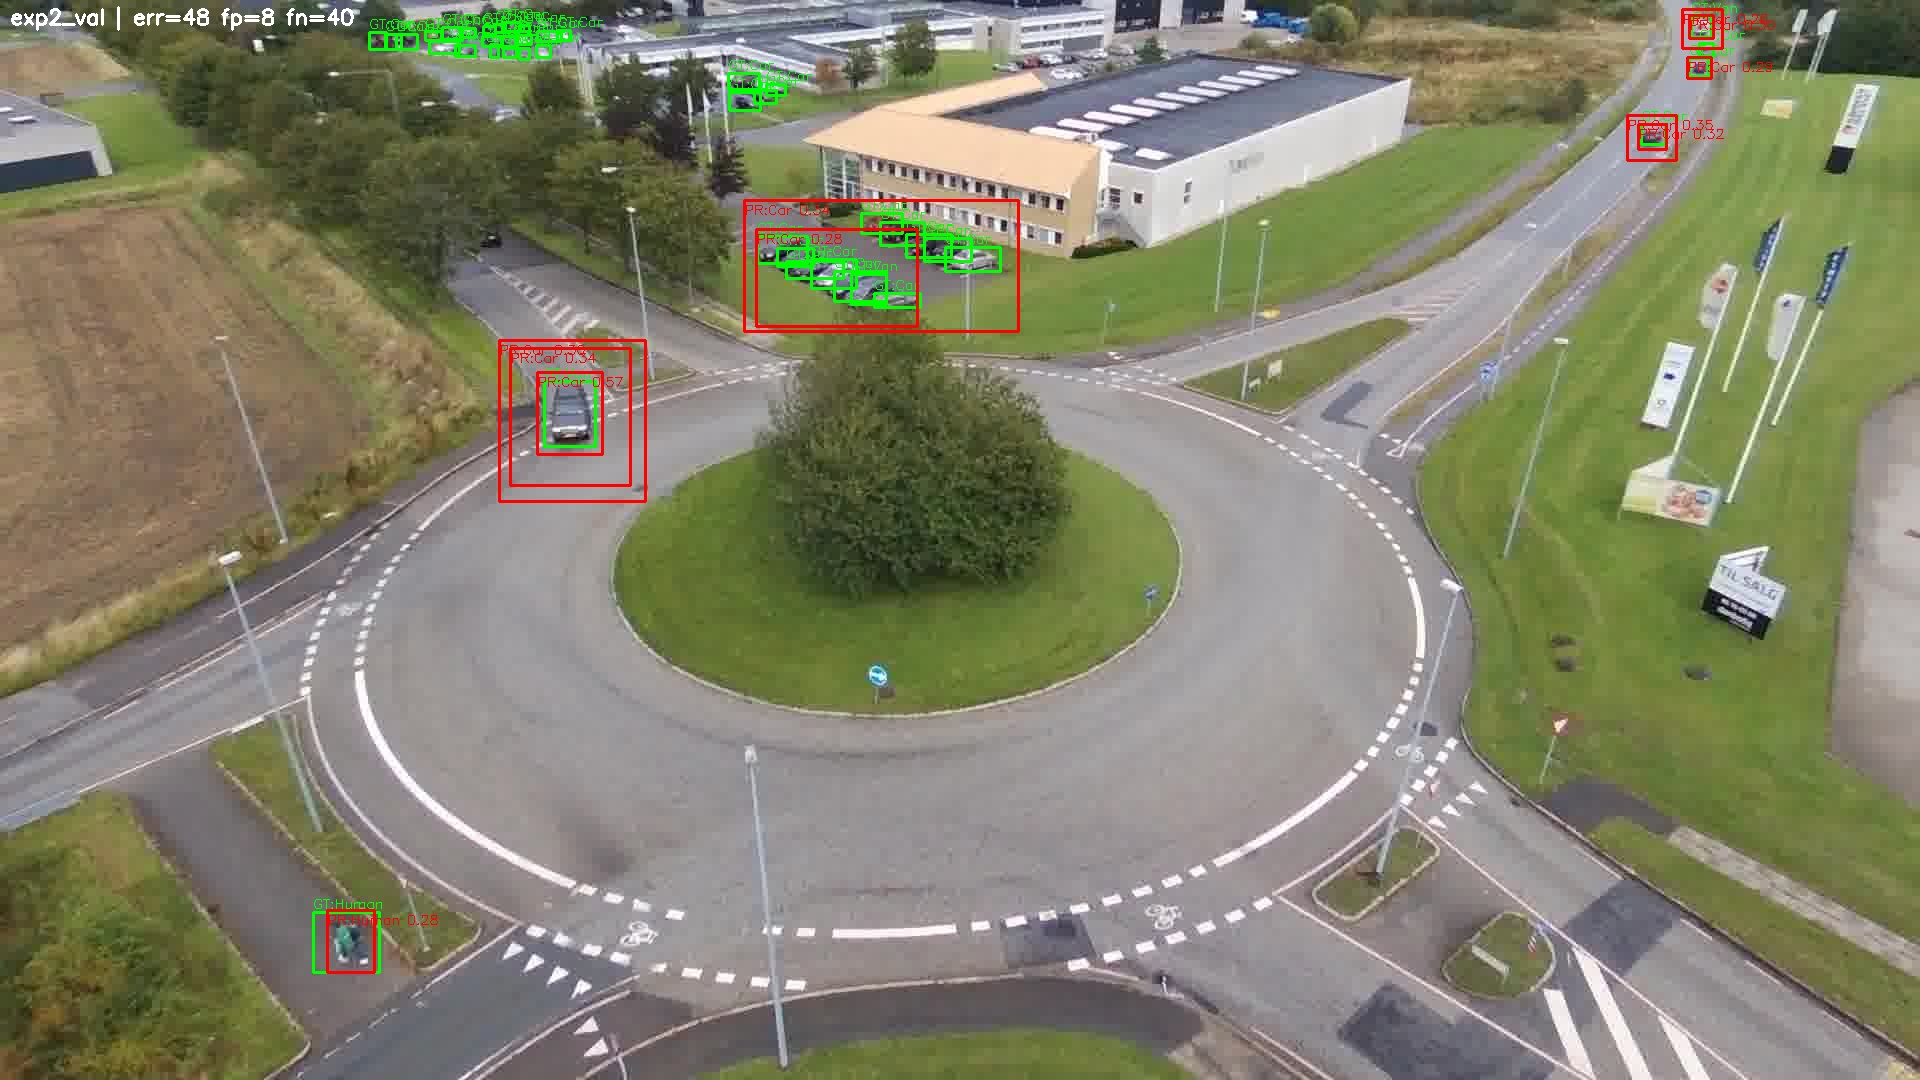

--------------------------------------------------------------------------------


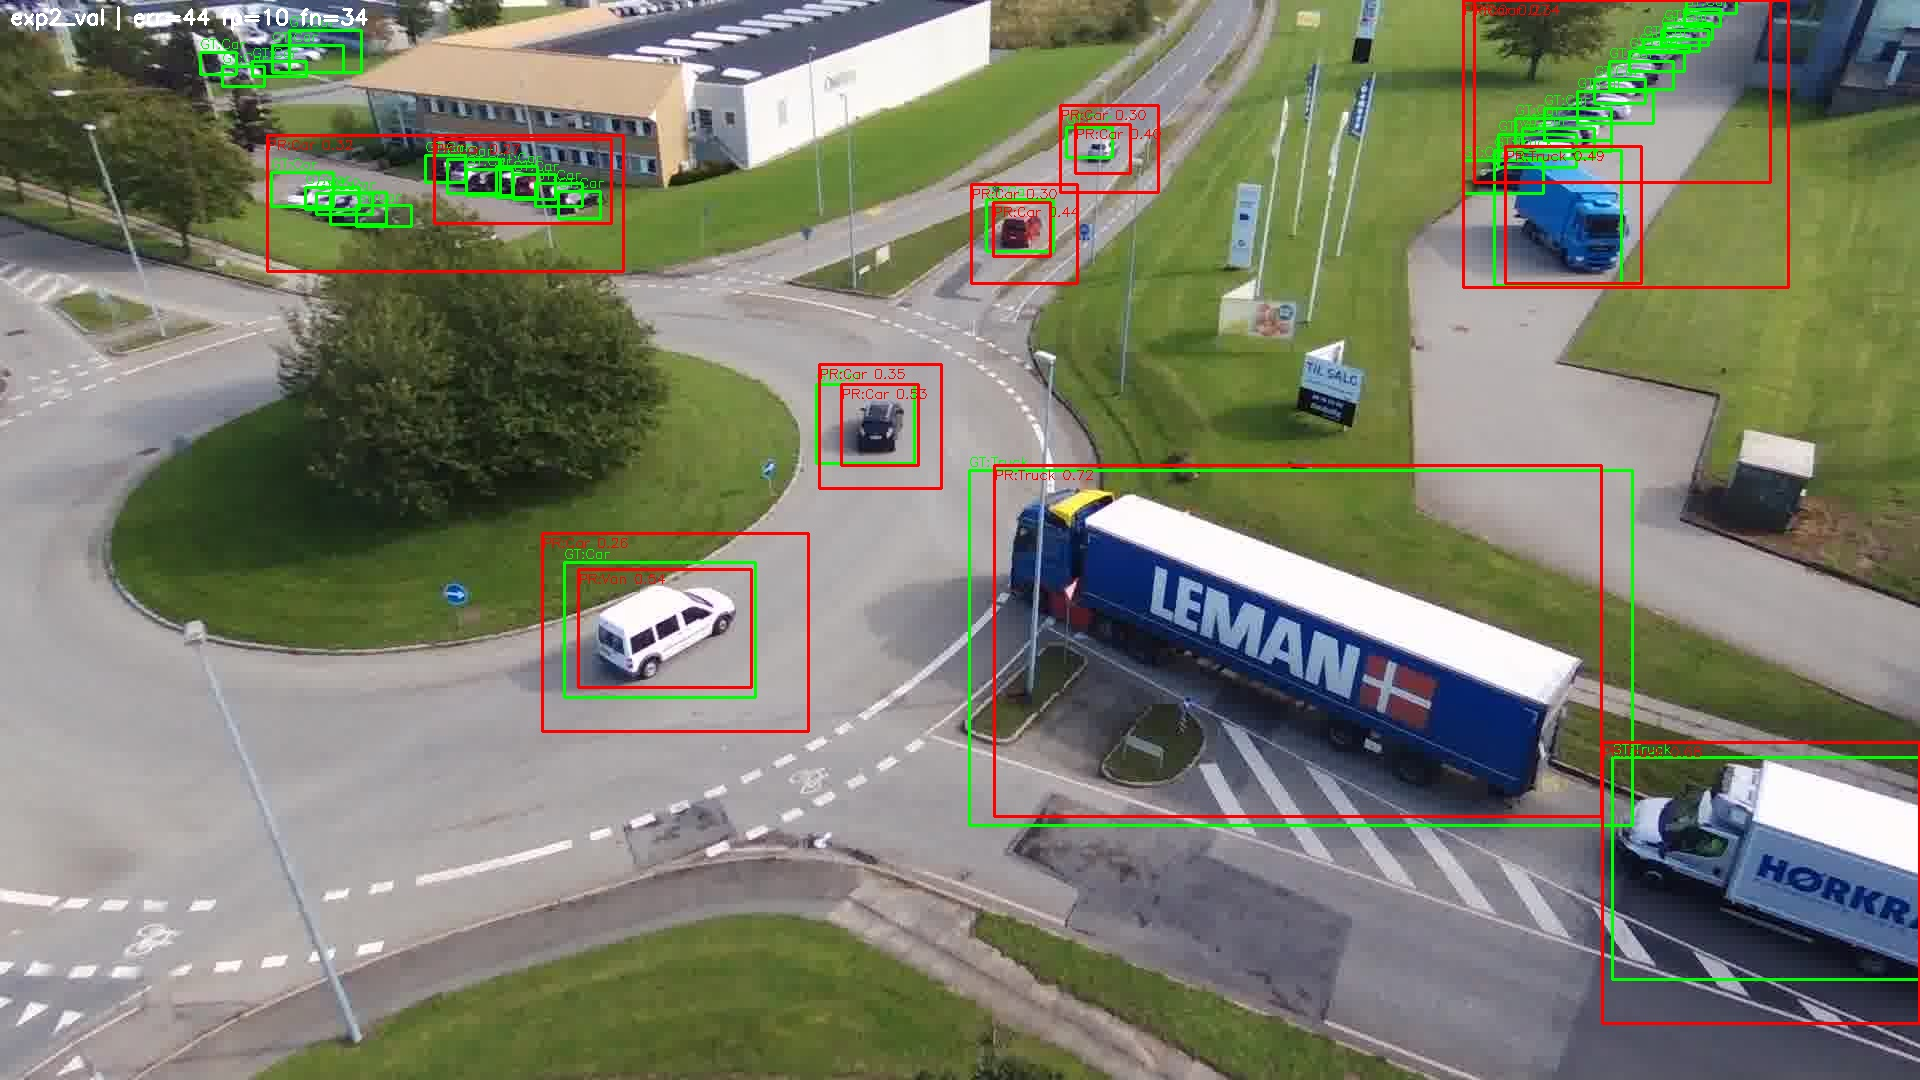

--------------------------------------------------------------------------------


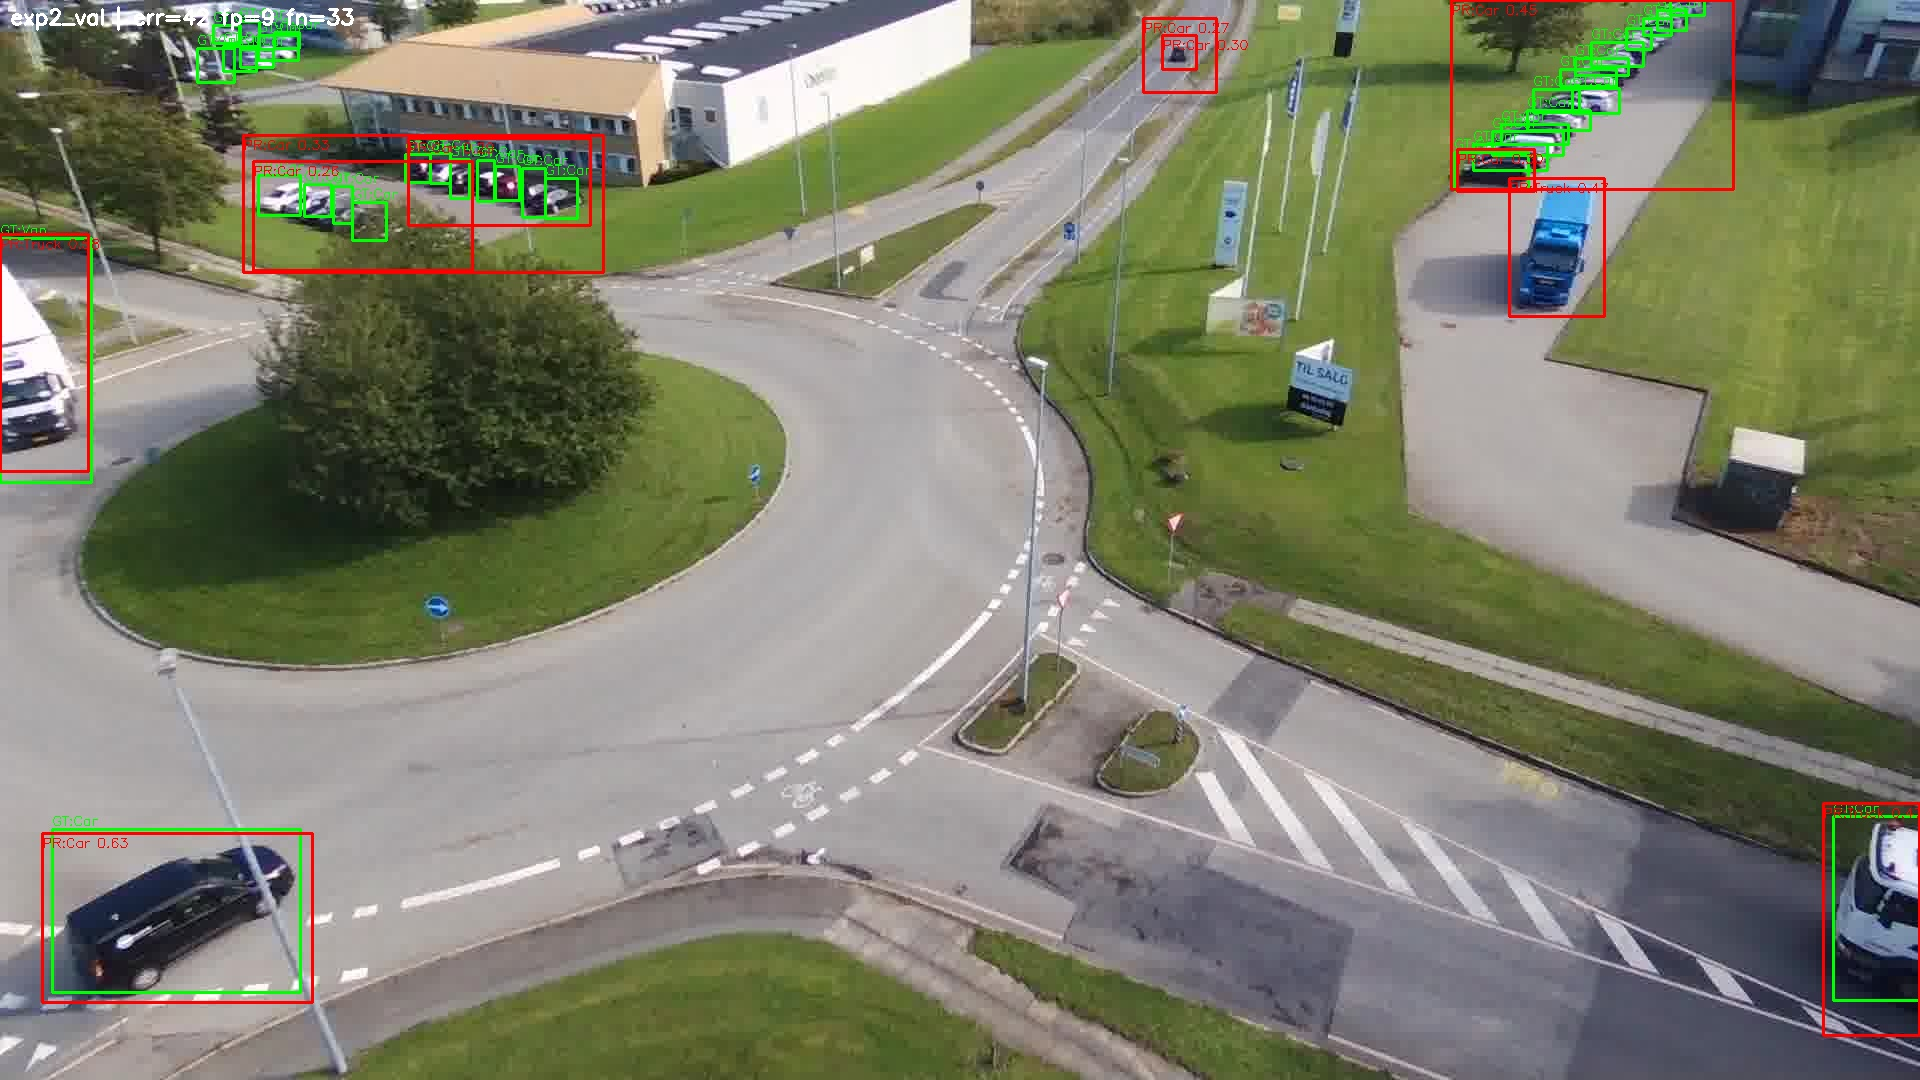

--------------------------------------------------------------------------------


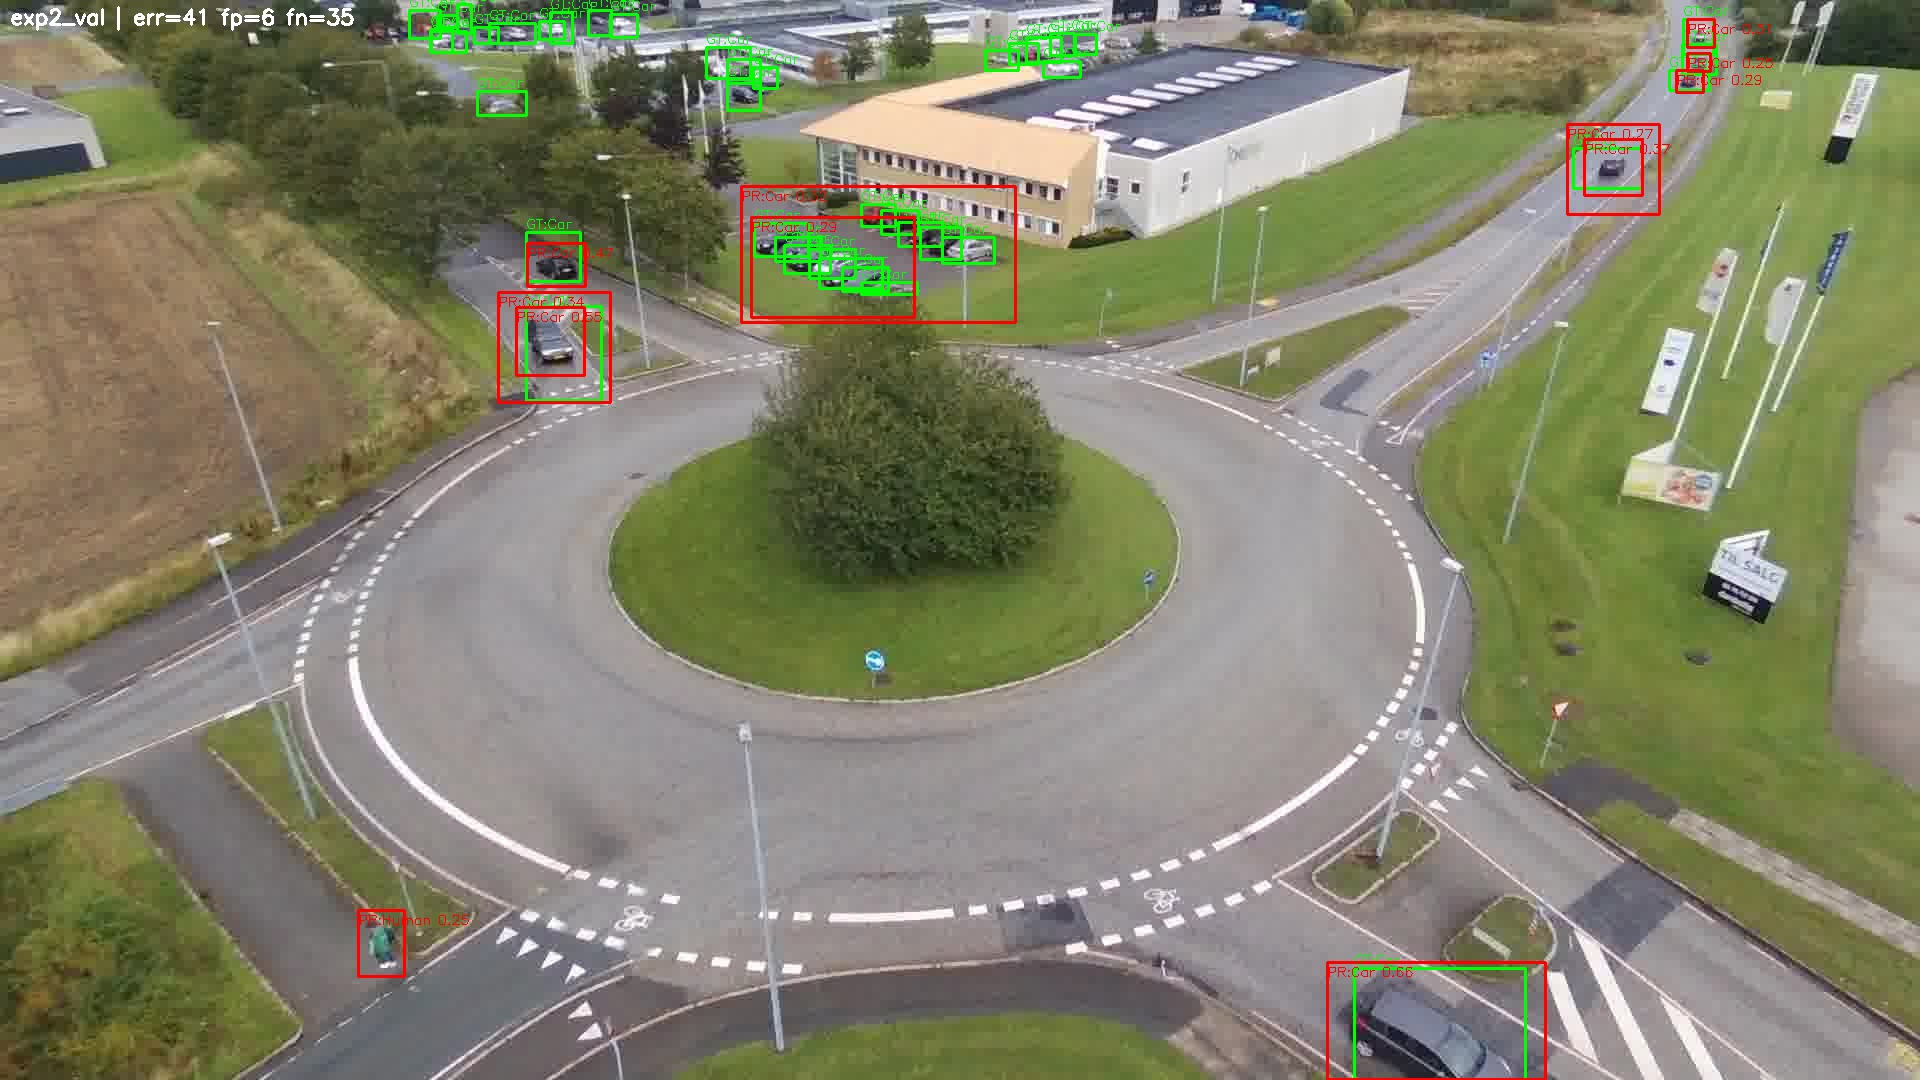

--------------------------------------------------------------------------------


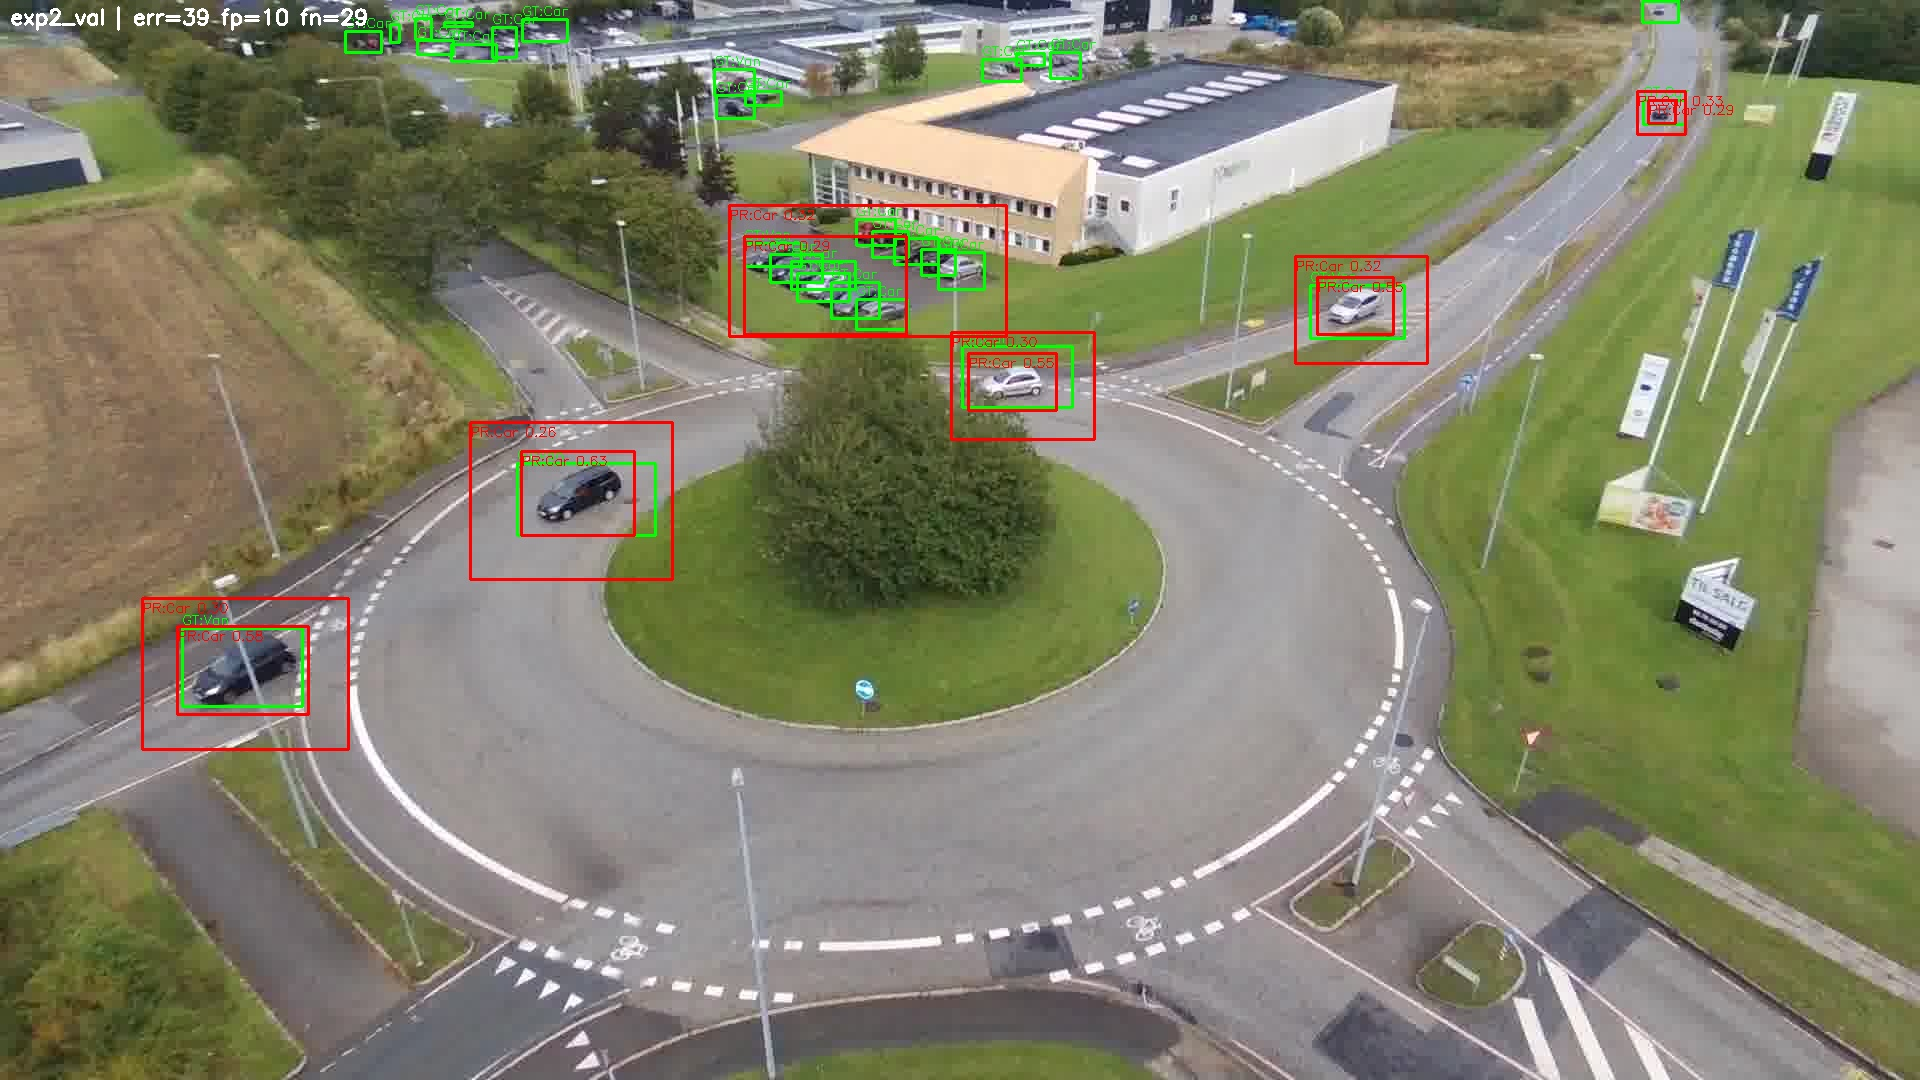

--------------------------------------------------------------------------------


In [ ]:
from IPython.display import Image, display
import glob

print("Exp2 modeli için yanlış tahminler (Hard Cases) hesaplanıyor...")
# Retrieve ground truth annotations and image paths for the validation set
coco_gt, image_paths, id_map = coco_from_split(Path(YOLO_ROOT), 'val')

# Load the model (using conf=0.25 to plot only this confidence level predictions)
model = RTDETR(str(exp2_best))
dt = normal_preds(model, image_paths, id_map, imgsz=960, conf=0.25, iou=0.5, max_det=300, chunk_size=128)


out_dir = RESULTS_ROOT / "wrong_predictions" / "exp2_best"
out_dir.mkdir(parents=True, exist_ok=True)

# Identify and plot the top 5 images with the highest error counts (FP + FN)
save_hard_case_visuals(
    coco_gt=coco_gt,
    image_paths=image_paths,
    id_map=id_map,
    detections=dt,
    out_dir=out_dir,
    mode_name="exp2_val",
    top_k=5,
    iou_thr=0.5
)

print("\n--- En çok hata yapılan (Yanlış Tahminler) 5 Resim ---")
print("Yeşil: Gerçek Etiket (Ground Truth)\nKırmızı: Model Tahmini (Prediction)")
for img_path in sorted(out_dir.glob("*.jpg")):
    display(Image(filename=str(img_path)))
    print("-"*80)


### Error Analysis: Impact of Inconsistent Labeling
The high error metrics observed in the outputs above—specifically the elevated False Negative (FN) rates and large grouped bounding boxes—are primarily artifacts of poor dataset quality.
An inspection of the raw dataset reveals severe **Labeling Inconsistencies**:
- **Background Deletion (High FN):** The model fails to detect small, distant vehicles because it was trained on noisy frames where background objects were entirely left unlabeled. It learned to treat these objects as negative space.(I showed inconsistent labelling photos in the report)
- **Cluster Merging:** The model incorrectly encapsulates dense parking areas within single, massive bounding boxes. This is identically mimicking poorly annotated training frames where individual cars were ignored in favor of one large group label.

SAHI sonuçları (Hard Cases) JSON dosyasından yükleniyor...

--- SAHI Kullanıldığında En Çok Hata Yapılan 5 Resim ---
Yeşil: Gerçek Etiket (Ground Truth)
Kırmızı: SAHI Tahmini (Prediction)


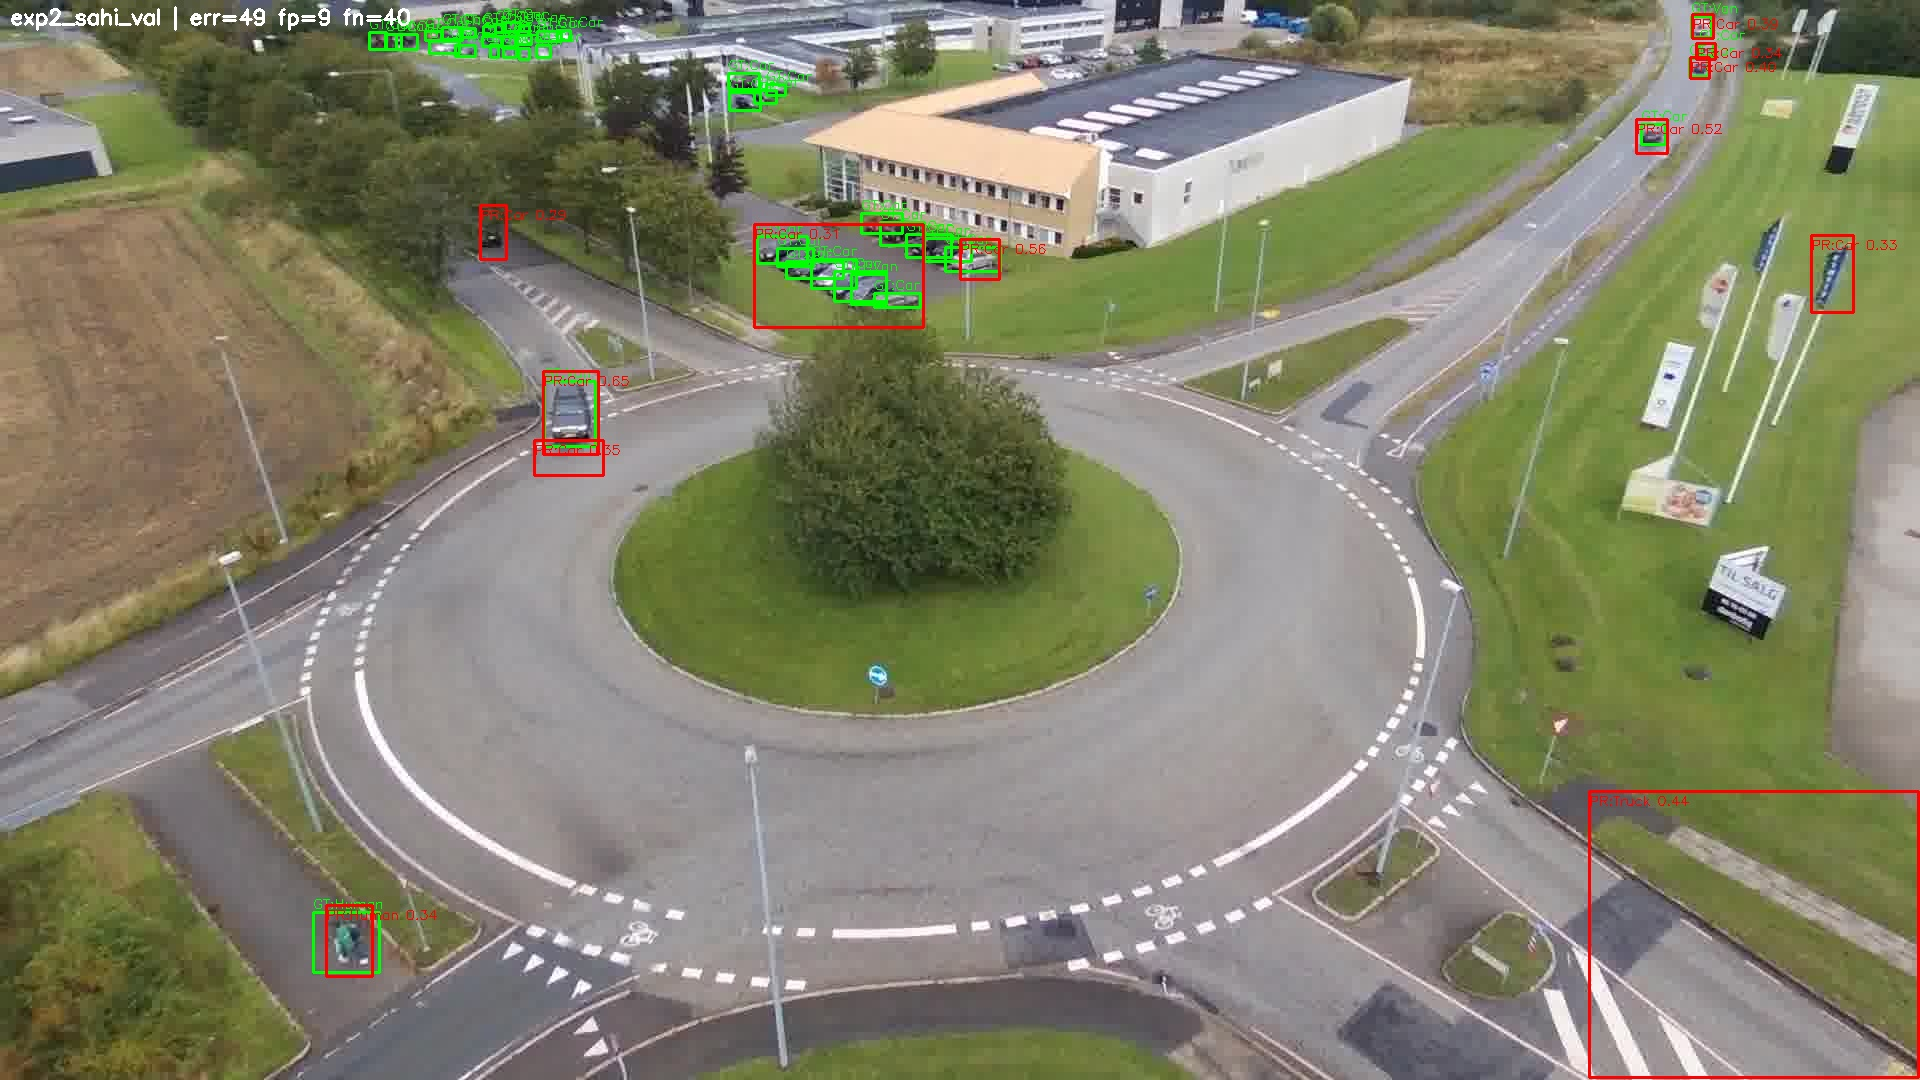

--------------------------------------------------------------------------------


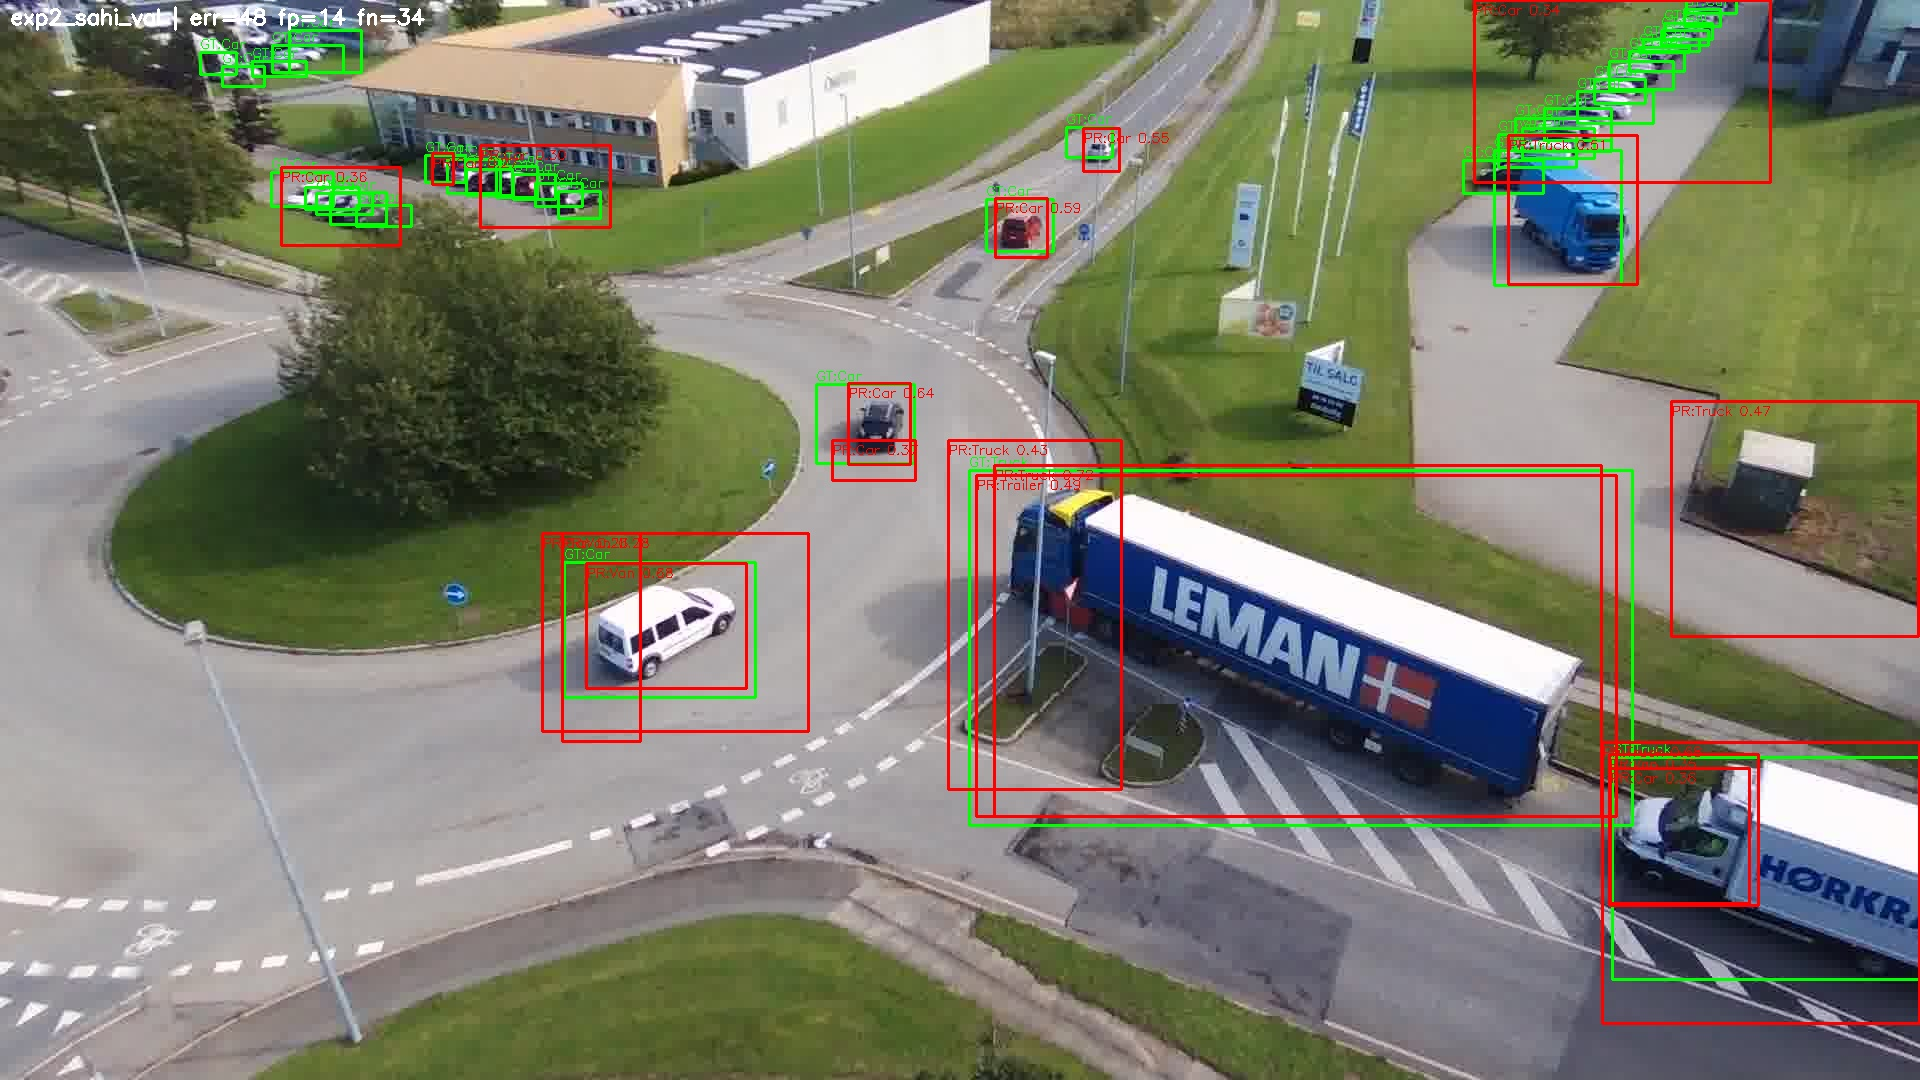

--------------------------------------------------------------------------------


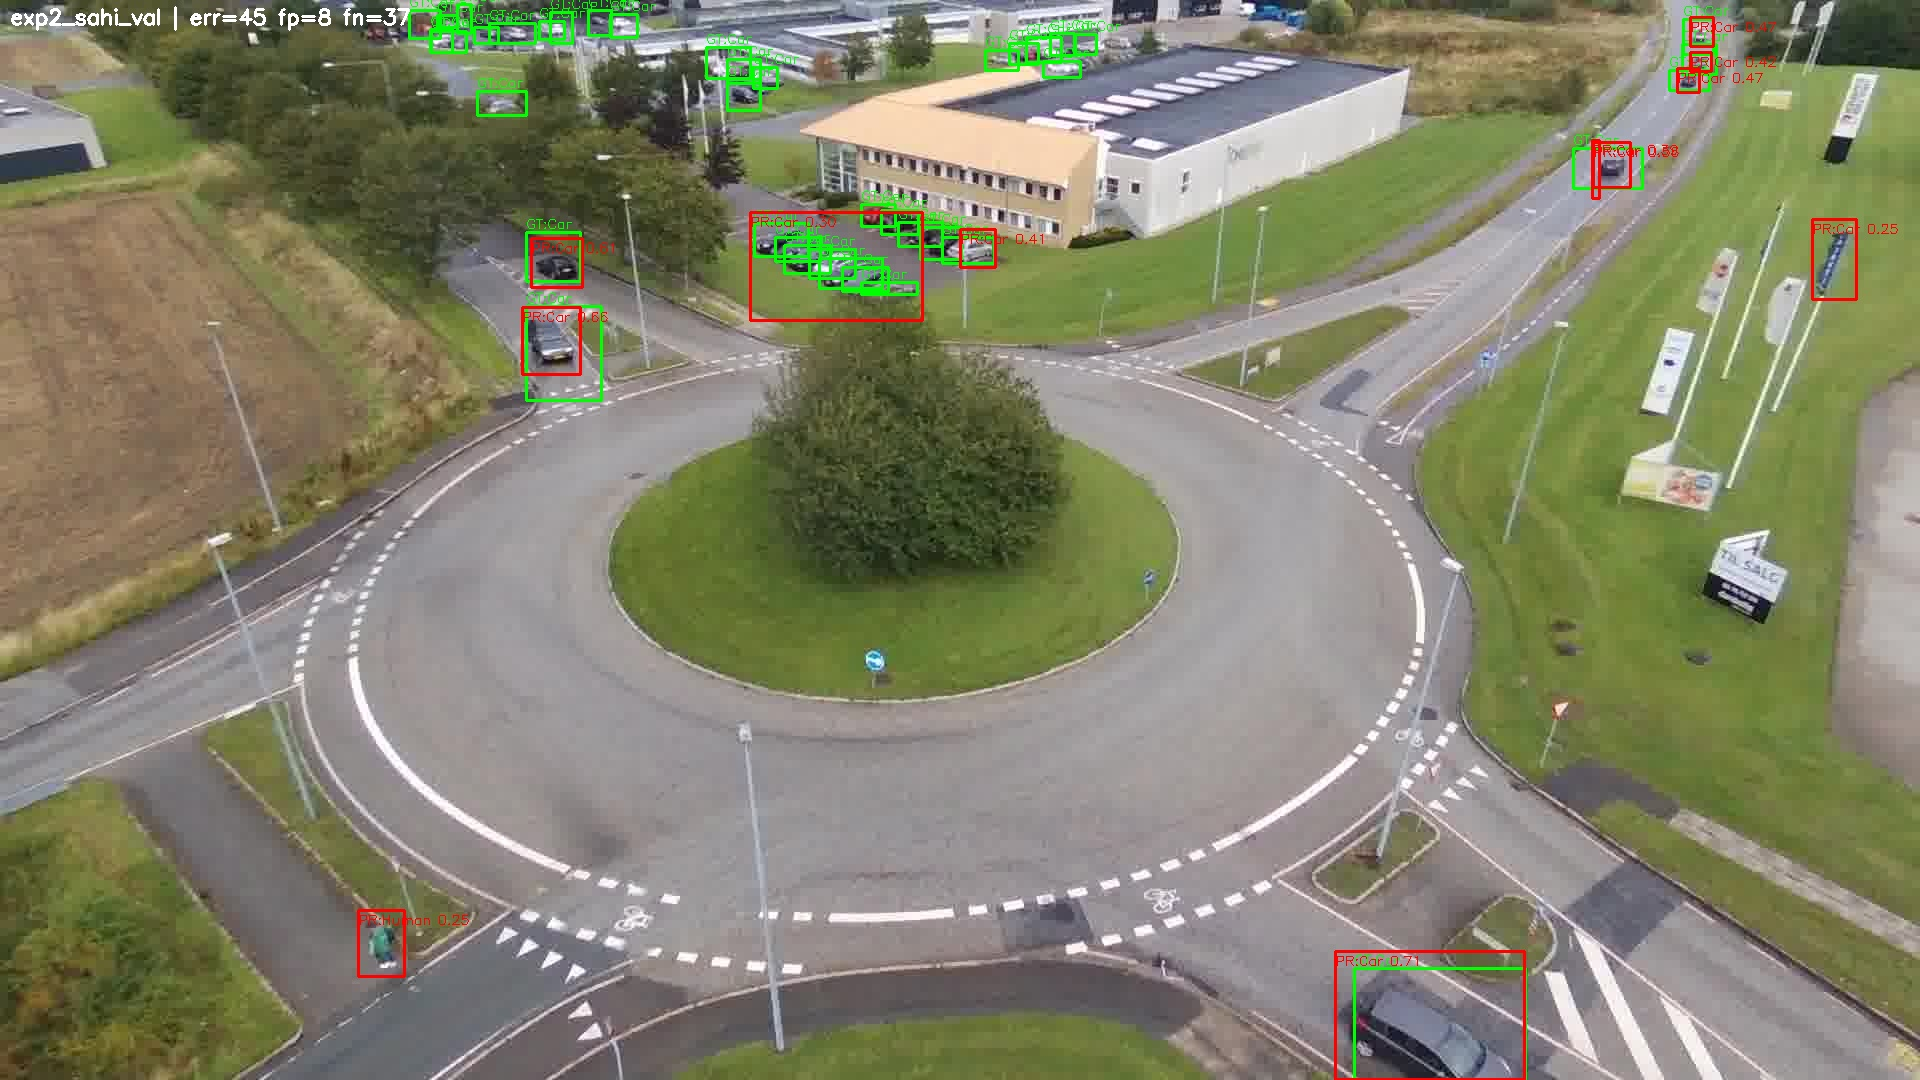

--------------------------------------------------------------------------------


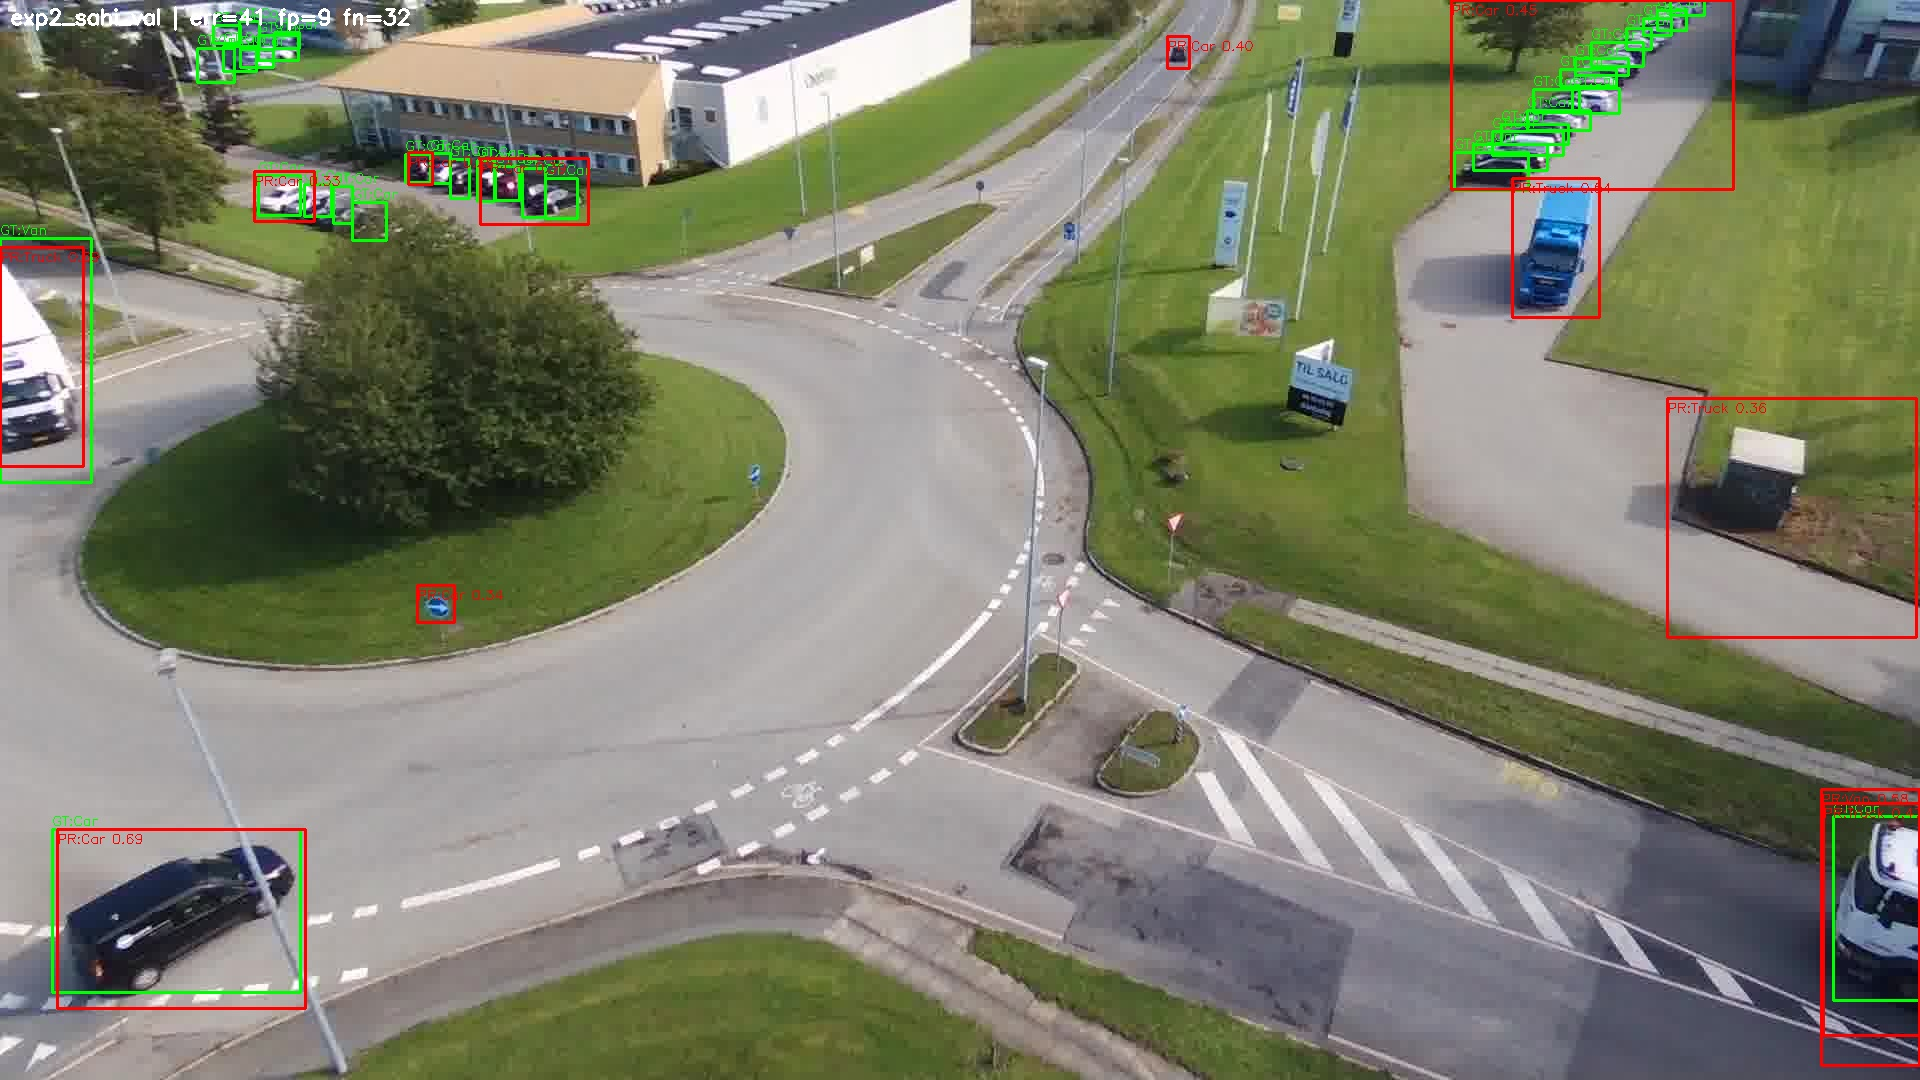

--------------------------------------------------------------------------------


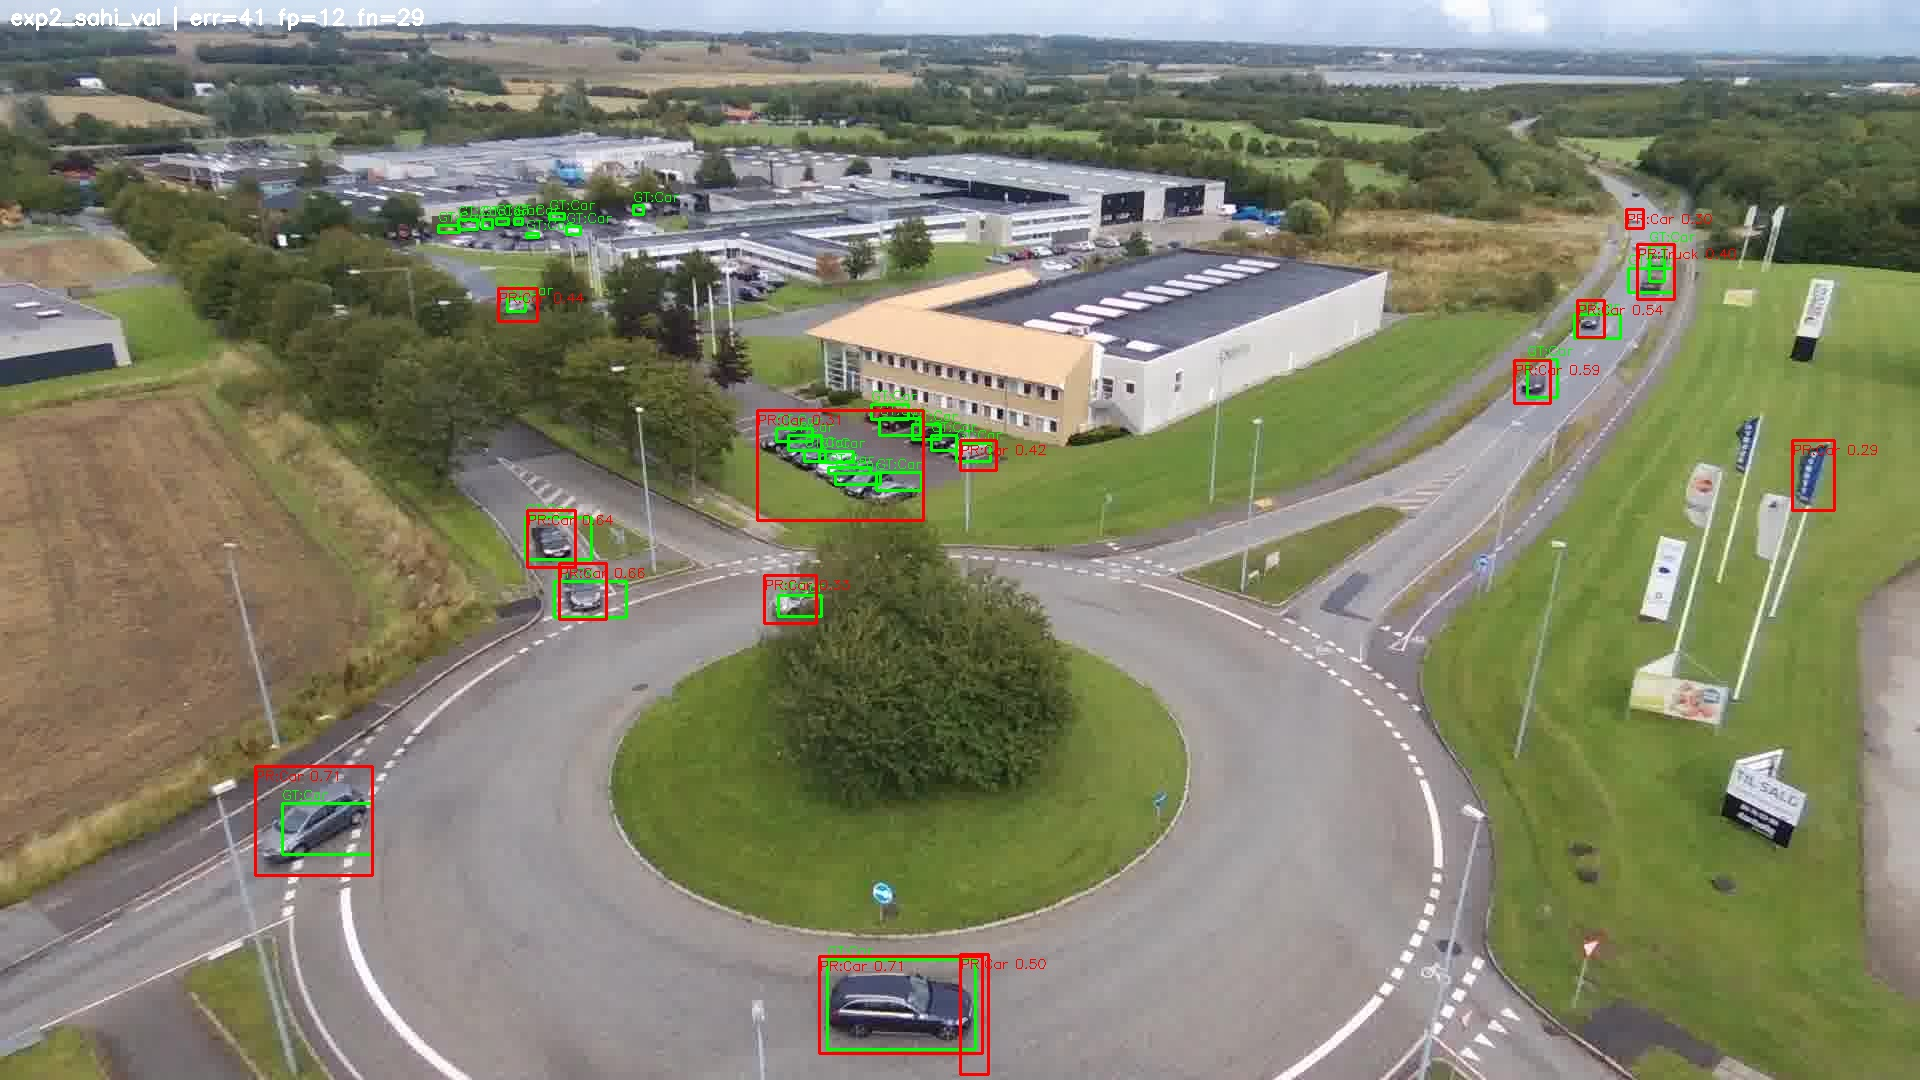

--------------------------------------------------------------------------------


In [ ]:
import json
from IPython.display import Image, display

print("SAHI sonuçları (Hard Cases) JSON dosyasından yükleniyor...")
sahi_json_path = RESULTS_ROOT / 'sahi_eval_exp2' / 'val' / 'sahi_predictions_coco.json'

if sahi_json_path.exists():
    with open(sahi_json_path, 'r') as f:
        sahi_dt = json.load(f)

    # SAHI için yanlış tahminleri kaydedeceğimiz klasör
    out_dir_sahi = RESULTS_ROOT / "wrong_predictions" / "exp2_sahi"
    out_dir_sahi.mkdir(parents=True, exist_ok=True)

    # En çok hata (FP + FN) yapılan 5 resmi tespit edip çizdiriyoruz
    save_hard_case_visuals(
        coco_gt=coco_gt,
        image_paths=image_paths,
        id_map=id_map,
        detections=sahi_dt,
        out_dir=out_dir_sahi,
        mode_name="exp2_sahi_val",
        top_k=5,
        iou_thr=0.5
    )

    print("\n--- SAHI Kullanıldığında En Çok Hata Yapılan 5 Resim ---")
    print("Yeşil: Gerçek Etiket (Ground Truth)\nKırmızı: SAHI Tahmini (Prediction)")
    for img_path in sorted(out_dir_sahi.glob("*.jpg")):
        display(Image(filename=str(img_path)))
        print("-"*80)


## Run SAHI ablation (val + test)




In [ ]:
if RUN_SAHI_EVAL:
    selected_model = exp2_best
    print('Evaluating model:', selected_model)

    summary_df, per_class_df = evaluate_sahi_pipeline(
        data_root=YOLO_ROOT,
        model_path=selected_model,
        out_root=str(RESULTS_ROOT / 'sahi_eval_exp2'),
        splits=('val', 'test'),
    )

    display(summary_df)
    display(per_class_df.head(20))
else:
    print('RUN_SAHI_EVAL=False -> skipped')



Evaluating model: /content/drive/MyDrive/di725_a2/colab_outputs/runs_di725/exp2/weights/best.pt
creating index...
index created!
Processing chunk 0/4914 with 128 images.
Processing chunk 128/4914 with 128 images.
Processing chunk 256/4914 with 128 images.
Processing chunk 384/4914 with 128 images.
Processing chunk 512/4914 with 128 images.
Processing chunk 640/4914 with 128 images.
Processing chunk 768/4914 with 128 images.
Processing chunk 896/4914 with 128 images.
Processing chunk 1024/4914 with 128 images.
Processing chunk 1152/4914 with 128 images.
Processing chunk 1280/4914 with 128 images.
Processing chunk 1408/4914 with 128 images.
Processing chunk 1536/4914 with 128 images.
Processing chunk 1664/4914 with 128 images.
Processing chunk 1792/4914 with 128 images.
Processing chunk 1920/4914 with 128 images.
Processing chunk 2048/4914 with 128 images.
Processing chunk 2176/4914 with 128 images.
Processing chunk 2304/4914 with 128 images.
Processing chunk 2432/4914 with 128 images.
P

,split,mode,images,predictions,map25,map50,map50_95,runtime_sec
0,val,normal,4914,42698,0.333314,0.217516,0.081923,212.772286
1,val,sahi,4914,42318,0.315379,0.170475,0.059173,2787.568860
2,test,normal,3909,40506,0.364352,0.244198,0.093217,165.539195
3,test,sahi,3909,44421,0.351235,0.194064,0.071805,2218.529452


,split,class_name,normal_ap25,normal_ap50,normal_ap50_95,sahi_ap25,sahi_ap50,sahi_ap50_95,delta_ap25,delta_ap50,delta_ap50_95
0,val,Human,0.416936,0.228622,0.070489,0.357997,0.158107,0.046872,-0.058939,-0.070514,-0.023617
1,val,Car,0.489212,0.333436,0.113361,0.473133,0.259415,0.080787,-0.016079,-0.074021,-0.032574
2,val,Truck,0.534142,0.445925,0.214965,0.502020,0.363086,0.156670,-0.032122,-0.082838,-0.058294
3,val,Van,0.413076,0.324424,0.140796,0.406023,0.279212,0.106273,-0.007053,-0.045212,-0.034523
4,val,Motorbike,0.414173,0.202611,0.047384,0.354171,0.111133,0.020737,-0.060002,-0.091477,-0.026647
5,val,Bicycle,0.232468,0.088090,0.025110,0.259891,0.081835,0.021637,0.027423,-0.006256,-0.003473
6,val,Bus,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,val,Trailer,0.166507,0.117020,0.043277,0.169796,0.111012,0.040410,0.003289,-0.006008,-0.002867
8,test,Human,0.382270,0.187013,0.050000,0.325842,0.117078,0.032378,-0.056428,-0.069935,-0.017622
9,test,Car,0.612096,0.396296,0.128934,0.557122,0.289109,0.085893,-0.054974,-0.107187,-0.043041


##  Build report-ready tables

Outputs:
- `results/report_tables/table_main_baseline_vs_model.csv`
- `results/report_tables/table_sahi_class_delta.csv`
- `results/report_tables/report_tables.md`




In [ ]:
import pandas as pd
from pathlib import Path

summary_df = pd.read_csv(RESULTS_ROOT / 'sahi_eval_exp2' / 'summary_metrics.csv')
per_class_df = pd.read_csv(RESULTS_ROOT / 'sahi_eval_exp2' / 'per_class_metrics.csv')

best_row = summary_df.sort_values('map50', ascending=False).iloc[0]
main_table = pd.DataFrame([
    {'Model': 'YOLOv3-tiny (baseline)', 'mAP@0.25': None, 'mAP@0.5': BASELINE_MAP50['YOLOv3-tiny'], 'mAP@0.5:0.95': None},
    {'Model': 'MobileNetV2-SSDLite (baseline)', 'mAP@0.25': None, 'mAP@0.5': BASELINE_MAP50['MobileNetV2-SSDLite'], 'mAP@0.5:0.95': None},
    {
        'Model': f"RT-DETR ({best_row['mode']}, {best_row['split']})",
        'mAP@0.25': float(best_row['map25']),
        'mAP@0.5': float(best_row['map50']),
        'mAP@0.5:0.95': float(best_row['map50_95']),
    },
])

sahi_delta = (
    per_class_df
    .groupby('class_name', as_index=False)[['delta_ap25', 'delta_ap50', 'delta_ap50_95']]
    .mean()
    .sort_values('delta_ap50', ascending=False)
)

out = RESULTS_ROOT / 'report_tables'
out.mkdir(parents=True, exist_ok=True)
main_table.to_csv(out / 'table_main_baseline_vs_model.csv', index=False)
sahi_delta.to_csv(out / 'table_sahi_class_delta.csv', index=False)

ablation_csv = RESULTS_ROOT / 'model_ablation' / 'summary_metrics.csv'
if ablation_csv.exists():
    ablation_df = pd.read_csv(ablation_csv)
    ablation_df.to_csv(out / 'table_model_ablation.csv', index=False)
else:
    ablation_df = None

md_text = '## Baseline vs Model\n\n' + main_table.to_markdown(index=False) + '\n\n'
md_text += '## SAHI Class-wise Average Delta\n\n' + sahi_delta.to_markdown(index=False) + '\n\n'
if ablation_df is not None:
    md_text += '## Model Ablation (No-Train / Exp / Freeze)\n\n' + ablation_df.to_markdown(index=False)

(out / 'report_tables.md').write_text(md_text, encoding='utf-8')

print('Saved report tables under:', out)
display(main_table)
display(sahi_delta)
if ablation_df is not None:
    display(ablation_df)



Saved report tables under: /content/results/report_tables


,Model,mAP@0.25,mAP@0.5,mAP@0.5:0.95
0,YOLOv3-tiny (baseline),NaN,30.220000,NaN
1,MobileNetV2-SSDLite (baseline),NaN,19.500000,NaN
2,"RT-DETR (normal, test)",0.364352,0.244198,0.093217


,class_name,delta_ap25,delta_ap50,delta_ap50_95
1,Bus,0.002399,0.000098,-0.001740
0,Bicycle,0.035099,-0.006068,-0.002564
5,Trailer,-0.015633,-0.022683,-0.009115
7,Van,-0.004230,-0.033681,-0.026368
4,Motorbike,0.017600,-0.064852,-0.019243
3,Human,-0.057683,-0.070225,-0.020620
2,Car,-0.035526,-0.090604,-0.037808
6,Truck,-0.066235,-0.100683,-0.059190


,model,split,imgsz,status,map25,map50,map50_95,runtime_sec,images,predictions
0,no_train_pretrained,val,960,ok,0.044728,0.013650,0.003692,216.744905,4914,1474200
1,exp1_10ep_mosaic0,val,640,ok,0.350965,0.238067,0.087777,185.862247,4914,1474200
2,exp2_10ep_mosaic0,val,960,ok,0.364505,0.239100,0.089128,218.963676,4914,1474200
3,exp2_freeze10_mosaic0,val,960,missing_checkpoint,NaN,NaN,NaN,NaN,0,0
